# `uq_analysis`: file-first UQ analysis (memory-friendly)

This notebook avoids building a single giant `df_all`.
Instead, it reads each eval CSV (ID + OOD) one at a time and produces small summary tables.

Key principle: **calibrate on ID validation only**, then apply calibration to ID test + OOD test.


In [1]:
# Setup + configuration.
# - Ensures project imports work from `<root>/notebooks`.
# - Selects the run prefix/tag to analyze (IMPORTANT: do not mix tags, e.g. _xs_ with _m_).
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple
import json
import sys
import numpy as np
import pandas as pd
import yaml
pd.set_option('display.max_columns', 500)
# Resolve project root
NOTEBOOK_DIR = Path.cwd().resolve()
if (NOTEBOOK_DIR / "scripts").is_dir() and (NOTEBOOK_DIR / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR
elif (NOTEBOOK_DIR.parent / "scripts").is_dir() and (NOTEBOOK_DIR.parent / "configs").is_dir():
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# ----------------
# USER KNOBS (defaults pulled from config)
# ----------------
CONFIG_PATH = PROJECT_ROOT / "configs" / "uq_analysis.yaml"
EVAL_ROOT = PROJECT_ROOT / "outputs" / "evals"
cfg: Dict = {}
if CONFIG_PATH.exists():
    try:
        cfg = yaml.safe_load(CONFIG_PATH.read_text()) or {}
    except Exception as e:
        print(f"[warn] failed to read config {CONFIG_PATH}: {e}")
settings_cfg = cfg.get('settings', {}) if isinstance(cfg, dict) else {}
def _normalize_prefix(v: Optional[str]) -> str:
    if not v:
        return ''
    p = str(v)
    if not p.startswith('_'):
        p = '_' + p
    return p
# Allow either `run_prefix` or legacy `run_tag` from settings/top-level; accept `_l` or `_l_`
run_prefix_raw = settings_cfg.get('run_prefix') or cfg.get('run_prefix')
run_tag_raw = settings_cfg.get('run_tag') or cfg.get('run_tag')
RUN_PREFIX = _normalize_prefix(run_prefix_raw or run_tag_raw)
RUN_TAG = RUN_PREFIX or '_m_'
# Allow overriding eval_root in config
settings_eval_root = settings_cfg.get('eval_root') or cfg.get('eval_root')
if settings_eval_root:
    EVAL_ROOT = (PROJECT_ROOT / settings_eval_root).resolve()
# Datasets (labels must match what the eval scripts used in filenames)
ID_LABEL = cfg.get('id_label', 'id')
OOD_LABELS_PRIMARY = cfg.get('ood_labels_primary', [])
OOD_LABELS_SECONDARY = cfg.get('ood_labels_secondary', [])
OOD_LABELS = cfg.get('ood_labels', ['knn_hard'])
# Large-error definition: top quantile of abs error under point baseline on ID test
LARGE_ERROR_QUANTILE = settings_cfg.get('large_error_quantile', cfg.get('large_error_quantile', 0.90))
# Calibration parameters (ID-val only)
N_RELIABILITY_BINS = cfg.get('n_reliability_bins', 10)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('EVAL_ROOT   :', EVAL_ROOT)
print('RUN_PREFIX  :', RUN_PREFIX)
print('RUN_TAG     :', RUN_TAG)
print('CONFIG_PATH :', CONFIG_PATH)


PROJECT_ROOT: /home/canelo/uncertainty_quantification
EVAL_ROOT   : /home/canelo/uncertainty_quantification/outputs/evals
RUN_PREFIX  : _l
RUN_TAG     : _l
CONFIG_PATH : /home/canelo/uncertainty_quantification/configs/uq_analysis.yaml


In [2]:
# Optional overrides (set to None to keep config defaults)
OVERRIDES = {
    # "run_prefix": None,  # e.g., "_l" or "_l_"
    # "ood_labels": None,  # e.g., ["knn_hard"]
}

if OVERRIDES:
    if OVERRIDES.get("run_prefix") is not None:
        RUN_PREFIX = OVERRIDES["run_prefix"]
        RUN_TAG = RUN_PREFIX
    if OVERRIDES.get("ood_labels") is not None:
        OOD_LABELS = OVERRIDES["ood_labels"]



In [3]:
# Discover eval directories for the selected RUN_TAG.
# This is intentionally simple and explicit to avoid mixing tags.

@dataclass(frozen=True)
class MethodSpec:
    key: str
    label: str
    head_type: str
    aleatoric_source: str
    epistemic_source: str
    kind: str  # "regression" | "ensemble" | "nf" | "dido"


# Core methods (as agreed): analytic + MC + ensemble (+ point baseline)
METHODS_CORE: List[MethodSpec] = [
    MethodSpec("point", "Point", "point", "none", "none", "regression"),
    MethodSpec("lpl_analytic", "Laplace (analytic)", "laplace", "analytic", "none", "regression"),
    MethodSpec("lpl_mc", "Laplace + MC", "laplace", "analytic", "mc", "regression"),
    MethodSpec("esm_lpl", "Laplace + ensemble", "laplace", "analytic", "ensemble", "ensemble"),
    MethodSpec("gau_analytic", "Gauss (analytic)", "gauss", "analytic", "none", "regression"),
    MethodSpec("gau_mc", "Gauss + MC", "gauss", "analytic", "mc", "regression"),
    MethodSpec("esm_gau", "Gauss + ensemble", "gauss", "analytic", "ensemble", "ensemble"),
]

# Auxiliary methods: NF, DIDO
METHODS_AUX: List[MethodSpec] = [
    MethodSpec("nf_lpl", "Laplace (NF)", "laplace", "nf", "none", "nf"),
    MethodSpec("nf_gau", "Gauss (NF)", "gauss", "nf", "none", "nf"),
    MethodSpec("dido_lpl", "Laplace + DIDO", "laplace", "analytic", "dido", "dido"),
    MethodSpec("dido_gau", "Gauss + DIDO", "gauss", "analytic", "dido", "dido"),
]

ENABLE_METHODS = cfg.get("enable_methods", {})
core_map = {
    "point": "point",
    "lpl_analytic": "laplace_analytic",
    "lpl_mc": "laplace_mc",
    "esm_lpl": "laplace_ensemble",
    "gau_analytic": "gauss_analytic",
    "gau_mc": "gauss_mc",
    "esm_gau": "gauss_ensemble",
}
aux_map = {
    "nf_lpl": "nf_laplace",
    "nf_gau": "nf_gauss",
    "dido_lpl": "dido_laplace",
    "dido_gau": "dido_gauss",
}
METHODS_CORE = [m for m in METHODS_CORE if ENABLE_METHODS.get(core_map.get(m.key, m.key), True)]
METHODS_AUX = [m for m in METHODS_AUX if ENABLE_METHODS.get(aux_map.get(m.key, m.key), True)]

# Use run_patterns/runs from config; prefix injected from RUN_PREFIX set in setup cell
run_patterns = cfg.get("run_patterns", {}) or {
    "point": "point{prefix}*",
    "laplace_analytic": "lpl{prefix}*",
    "laplace_mc": "lpl{prefix}*",
    "gauss_analytic": "gau{prefix}*",
    "gauss_mc": "gau{prefix}*",
    "laplace_ensemble": "esm_laplace_lpl{prefix}*",
    "gauss_ensemble": "esm_gauss_gau{prefix}*",
    "nf_laplace": "nf_lpl{prefix}*",
    "nf_gauss": "nf_gau{prefix}*",
    "dido_laplace": "dido_lpl{prefix}*",
    "dido_gauss": "dido_gau{prefix}*",
}
run_overrides = cfg.get("runs", {}) or {}


def _pick_latest_dir(glob_pat: str):
    matches = sorted(EVAL_ROOT.glob(glob_pat))
    return matches[-1] if matches else None


def _resolve_run(pattern_key: str):
    explicit = run_overrides.get(pattern_key)
    if explicit:
        p = Path(explicit)
        return p if p.exists() else None
    pat = run_patterns.get(pattern_key)
    if not pat:
        return None
    pat = pat.format(prefix=RUN_PREFIX)
    return _pick_latest_dir(pat)

# map spec.key prefix to pattern keys
RUN_DIRS: Dict[str, Path] = {}
run_map = {
    "point": "point",
    "lpl": "laplace_mc",
    "gau": "gauss_mc",
    "esm_lpl": "laplace_ensemble",
    "esm_gau": "gauss_ensemble",
    "nf_lpl": "nf_laplace",
    "nf_gau": "nf_gauss",
    "dido_lpl": "dido_laplace",
    "dido_gau": "dido_gauss",
}
for key, pattern_key in run_map.items():
    RUN_DIRS[key] = _resolve_run(pattern_key)

print(f"Resolved eval dirs (prefix='{RUN_PREFIX}'):")
for k, p in RUN_DIRS.items():
    print(f"  {k:10s}: {p}")



Resolved eval dirs (prefix='_l'):
  point     : /home/canelo/uncertainty_quantification/outputs/evals/point_l_20251220-010530_303656
  lpl       : /home/canelo/uncertainty_quantification/outputs/evals/lpl_l_20251220-010458_303655
  gau       : /home/canelo/uncertainty_quantification/outputs/evals/gau_l_20251220-013128_303690
  esm_lpl   : None
  esm_gau   : None
  nf_lpl    : None
  nf_gau    : None
  dido_lpl  : None
  dido_gau  : None


In [4]:
# Helpers to load *one* eval file at a time and map to a common schema.
# This is the core memory-saving change: no global concat.
def _read_csv_usecols(path: Path, usecols: List[str]) -> pd.DataFrame:
    # Use intersection only to be robust to minor schema changes.
    cols = pd.read_csv(path, nrows=0).columns.tolist()
    keep = [c for c in usecols if c in cols]
    return pd.read_csv(path, usecols=keep)
def _first_existing(base: Path, names: List[str]) -> Path:
    for name in names:
        p = base / name
        if p.exists():
            return p
    return base / names[0]
def load_id_regression(run_dir: Path, split: str, *, variant: str) -> pd.DataFrame:
    """variant: "point" | "analytic" | "mc" """
    run_dir = Path(run_dir)
    if variant == "point":
        path = _first_existing(run_dir, [f"{split}_preds.csv", f"preds_{split}.csv"])
        df = _read_csv_usecols(path, ["id", "split", "head_type", "y_true", "y_pred"]) 
        df = df.rename(columns={"y_pred": "mu"})
        df["sigma_ale_raw"] = np.nan
        df["sigma_epi_raw"] = np.nan
        return df
    if variant == "analytic":
        candidates = [
            f"{split}_preds.csv",
            f"preds_{split}.csv",
            f"mc_preds_{split}.csv",
        ]
        path = _first_existing(run_dir, candidates)
        df = _read_csv_usecols(
            path,
            ["id", "split", "head_type", "y_true", "y_pred_det", "y_pred_mc_mean", "sigma_ale_raw", "sigma_ale_orig", "sigma_epi_raw", "sigma_epi_orig"],
        )
        if "y_pred_det" in df.columns:
            df = df.rename(columns={"y_pred_det": "mu"})
        elif "y_pred_mc_mean" in df.columns:
            df = df.rename(columns={"y_pred_mc_mean": "mu"})
        if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
            df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
        if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
            df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
        df["sigma_epi_raw"] = np.nan  # analytic ignores epistemic here
        if "mu" not in df.columns:
            df["mu"] = np.nan
        if "sigma_ale_raw" not in df.columns:
            df["sigma_ale_raw"] = np.nan
        return df
    if variant == "mc":
        candidates = [
            f"mc_preds_{split}.csv",
            f"{split}_preds.csv",
            f"preds_{split}.csv",
        ]
        path = _first_existing(run_dir, candidates)
        df = _read_csv_usecols(
            path,
            ["id", "split", "head_type", "y_true", "y_pred_mc_mean", "sigma_ale_orig", "sigma_epi_orig"],
        )
        df = df.rename(
            columns={
                "y_pred_mc_mean": "mu",
                "sigma_ale_orig": "sigma_ale_raw",
                "sigma_epi_orig": "sigma_epi_raw",
            }
        )
        return df
    raise ValueError(f"unknown variant={variant}")
def load_id_ensemble(run_dir: Path, split: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    fname = f"ensemble_preds_{split}.csv"
    path = run_dir / fname
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            # Newer ensemble eval schema
            "y_pred_ens_mean",
            "sigma_ale_ens",
            "sigma_epi_ens",
            # Older/alternate names
            "y_pred_mean",
            "y_pred_method",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )
    # Standardize prediction
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    # Standardize sigmas
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    elif "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    elif "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    # Ensure required columns exist
    if "mu" not in df.columns:
        df["mu"] = np.nan
    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df
def load_id_nf(run_dir: Path) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / "flow_eval_test.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig"],
    )
    df = df.rename(
        columns={
            "y_true_orig": "y_true",
            "y_pred_base_orig": "mu",
            "sigma_base_orig": "sigma_ale_raw",
        }
    )
    df["sigma_epi_raw"] = 0.0
    return df
def load_id_dido(run_dir: Path) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / "dido_test.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"],
    )
    return df
def load_ood_regression(run_dir: Path, label: str, *, variant: str | None = None) -> pd.DataFrame:
    """Load OOD eval outputs for a base regression run.
    variant:
      - None / "analytic" / "point": reads `ood_<label>_test.csv`
      - "mc": reads `mc_preds_ood_<label>.csv` (includes epistemic sigma)
    """
    run_dir = Path(run_dir)
    if variant == "mc":
        path = run_dir / f"mc_preds_ood_{label}.csv"
        df = _read_csv_usecols(
            path,
            [
                "id",
                "split",
                "head_type",
                "y_true",
                "y_pred_mc_mean",
                "y_pred_det",
                "sigma_ale_orig",
                "sigma_epi_orig",
            ],
        )
        if "y_pred_mc_mean" in df.columns:
            df = df.rename(columns={"y_pred_mc_mean": "mu"})
        elif "y_pred_det" in df.columns:
            df = df.rename(columns={"y_pred_det": "mu"})
        df = df.rename(
            columns={
                "sigma_ale_orig": "sigma_ale_raw",
                "sigma_epi_orig": "sigma_epi_raw",
            }
        )
        if "sigma_ale_raw" not in df.columns:
            df["sigma_ale_raw"] = np.nan
        if "sigma_epi_raw" not in df.columns:
            df["sigma_epi_raw"] = np.nan
        return df
    path = run_dir / f"ood_{label}_test.csv"
    df = _read_csv_usecols(
        path,
        [
            "id",
            "split",
            "head_type",
            "y_true",
            "y_pred_det",
            "y_pred_mean",
            "y_pred_method",
            "y_pred",
            "y_pred_mc_mean",
            "sigma_ale_raw",
            "sigma_epi_raw",
            "sigma_ale_orig",
            "sigma_epi_orig",
        ],
    )
    # Standardize prediction -> mu
    if "y_pred_det" in df.columns:
        df = df.rename(columns={"y_pred_det": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    elif "y_pred" in df.columns:
        df = df.rename(columns={"y_pred": "mu"})
    elif "y_pred_mc_mean" in df.columns:
        df = df.rename(columns={"y_pred_mc_mean": "mu"})
    else:
        raise ValueError(f"No prediction column found in {path}")
    # Standardize sigmas (analytic heads typically only have aleatoric)
    if "sigma_ale_raw" not in df.columns and "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    if "sigma_epi_raw" not in df.columns and "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    if "sigma_ale_raw" not in df.columns:
        df["sigma_ale_raw"] = np.nan
    if "sigma_epi_raw" not in df.columns:
        df["sigma_epi_raw"] = np.nan
    return df
def load_ood_nf(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / f"flow_eval_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "y_true_orig", "y_pred_base_orig", "sigma_base_orig"],
    )
    df = df.rename(
        columns={
            "y_true_orig": "y_true",
            "y_pred_base_orig": "mu",
            "sigma_base_orig": "sigma_ale_raw",
        }
    )
    df["sigma_epi_raw"] = 0.0
    return df
def load_ood_dido(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    path = run_dir / f"dido_ood_{label}.csv"
    df = _read_csv_usecols(
        path,
        ["id", "split", "head_type", "dido_strength_raw", "dido_vacuity_raw", "dido_entropy_raw"],
    )
    return df


In [5]:
# Compute the large-error threshold tau from the point baseline on ID test.
# This tau is used across methods (method-agnostic definition).

point_dir = RUN_DIRS.get("point")
if point_dir is None:
    raise FileNotFoundError("No point eval dir found for RUN_TAG")

df_point_test = load_id_regression(point_dir, split="test", variant="point")
abs_err_point = np.abs(df_point_test["y_true"].to_numpy(float) - df_point_test["mu"].to_numpy(float))
LARGE_ERROR_TAU = float(np.quantile(abs_err_point, LARGE_ERROR_QUANTILE))
print(f"LARGE_ERROR_TAU (point ID test, q={LARGE_ERROR_QUANTILE:.2f}): {LARGE_ERROR_TAU:.4f}")


LARGE_ERROR_TAU (point ID test, q=0.95): 7939.7084


In [6]:
def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    def _require(key: str) -> Path:
        p = RUN_DIRS.get(key)
        if p is None:
            raise FileNotFoundError(f"No eval dir for {key}; check run_prefix/runs config")
        return p
    if spec.key == "point":
        return load_id_regression(_require("point"), split="test", variant="point")
    if spec.key.startswith("lpl_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(_require("lpl"), split="test", variant="mc")
        return load_id_regression(_require("lpl"), split="test", variant="analytic")
    if spec.key.startswith("gau_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(_require("gau"), split="test", variant="mc")
        return load_id_regression(_require("gau"), split="test", variant="analytic")
    if spec.epistemic_source == "ensemble":
        if spec.head_type == "laplace":
            return load_id_ensemble(_require("esm_lpl"), split="test")
        return load_id_ensemble(_require("esm_gau"), split="test")
    raise ValueError(f"Unhandled core spec: {spec}")



In [7]:
# Compute core ID-test metrics (file-first).
# Produces a small summary table; does NOT build a giant df.
from scripts.uq_eval import gaussian_nll
from scipy.stats import norm
def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]
    mu = mu[mask]
    sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))
# Calibration maps (may be empty if calibration not run)
try:
    alpha
except NameError:
    alpha = {}
try:
    beta
except NameError:
    beta = {}
if not alpha:
    alpha_cfg = cfg.get("alpha", {})
    alpha = alpha_cfg if isinstance(alpha_cfg, dict) else {}
if not beta:
    beta_cfg = cfg.get("beta", {})
    beta = beta_cfg if isinstance(beta_cfg, dict) else {}
if not alpha and not beta:
    print("[info] No calibration parameters found; using raw sigmas (alpha=beta=1).")
def calibrated_sigmas(
    *,
    head_type: str,
    ale_src: str,
    epi_src: str,
    sigma_ale_raw: np.ndarray,
    sigma_epi_raw: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # If NF doesn't have its own alpha (no val flow files), fall back to analytic alpha.
    def _alpha_lookup(ht: str, asrc: str) -> float:
        if (ht, asrc) in alpha:
            return float(alpha[(ht, asrc)])
        if asrc == "nf" and (ht, "analytic") in alpha:
            return float(alpha[(ht, "analytic")])
        return 1.0
    a = _alpha_lookup(head_type, ale_src)
    b = float(beta.get((head_type, ale_src, epi_src), 1.0))
    s_a2 = a * (np.asarray(sigma_ale_raw, float) ** 2)
    s_e2 = b * (np.asarray(sigma_epi_raw, float) ** 2)
    s_a = np.sqrt(np.maximum(s_a2, 0.0))
    s_e = np.sqrt(np.maximum(s_e2, 0.0))
    s_t = np.sqrt(np.maximum(s_a2 + s_e2, 0.0))
    return s_a, s_e, s_t
def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    if spec.key == "point":
        return load_id_regression(RUN_DIRS["point"], split="test", variant="point")
    if spec.key.startswith("lpl_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["lpl"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["lpl"], split="test", variant="analytic")
    if spec.key.startswith("gau_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["gau"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["gau"], split="test", variant="analytic")
    if spec.epistemic_source == "ensemble":
        if spec.head_type == "laplace":
            return load_id_ensemble(RUN_DIRS["esm_lpl"], split="test")
        return load_id_ensemble(RUN_DIRS["esm_gau"], split="test")
    raise ValueError(f"Unhandled core spec: {spec}")


[info] No calibration parameters found; using raw sigmas (alpha=beta=1).


In [ ]:
# Fit simple alpha/beta calibration on ID validation splits and print results.
# Toggle CALIB_OBJ between "nll" and "crps" to choose the objective.
# If calibration is not desired, skip this cell; downstream will use raw sigmas.

import numpy as np
import pandas as pd
from scipy.stats import norm as _norm

CALIB_OBJ = "nll"  # "nll" | "crps"

def _gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]; mu = mu[mask]; sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * _norm.cdf(z) - 1) + 2 * _norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

def method_id_val_frame(spec: MethodSpec) -> pd.DataFrame:
    if spec.key == "point":
        return load_id_regression(RUN_DIRS["point"], split="val", variant="point")
    if spec.key.startswith("lpl_"):
        return load_id_regression(RUN_DIRS["lpl"], split="val", variant="mc" if spec.epistemic_source == "mc" else "analytic")
    if spec.key.startswith("gau_"):
        return load_id_regression(RUN_DIRS["gau"], split="val", variant="mc" if spec.epistemic_source == "mc" else "analytic")
    if spec.epistemic_source == "ensemble":
        return load_id_ensemble(RUN_DIRS["esm_lpl" if spec.head_type == "laplace" else "esm_gau"], split="val")
    raise ValueError(f"Unhandled spec for val load: {spec}")

def _fit_scale_crps(y, mu, s_a2, s_e2, mask):
    scales = np.logspace(-2, 2, num=9)
    best_crps = float("inf")
    best_a = best_b = 1.0
    y_m = y[mask]; mu_m = mu[mask]
    for a_mult in scales:
        for b_mult in scales:
            sigma = np.sqrt(np.maximum(a_mult * s_a2 + b_mult * s_e2, 0.0))
            crps_val = _gaussian_crps_mean(y_m, mu_m, sigma[mask])
            if np.isfinite(crps_val) and crps_val < best_crps:
                best_crps, best_a, best_b = crps_val, a_mult, b_mult
    return best_a, best_b

alpha = {}
beta = {}

for spec in METHODS_CORE:
    if spec.head_type == "point":
        continue
    try:
        df_val = method_id_val_frame(spec)
    except FileNotFoundError as e:
        print(f"[skip calib] {spec.label}: {e}")
        continue

    y = df_val["y_true"].to_numpy(float)
    mu = df_val["mu"].to_numpy(float)
    err2 = (y - mu) ** 2
    s_a = df_val.get("sigma_ale_raw", pd.Series(np.nan, index=df_val.index)).to_numpy(float)
    s_e = df_val.get("sigma_epi_raw", pd.Series(0.0, index=df_val.index)).fillna(0.0).to_numpy(float)
    s_a2 = np.nan_to_num(s_a, nan=0.0) ** 2
    s_e2 = np.nan_to_num(s_e, nan=0.0) ** 2

    mask = np.isfinite(err2) & np.isfinite(s_a2) & np.isfinite(s_e2)
    if not np.any(mask):
        print(f"[skip calib] {spec.label}: no finite data")
        continue

    if CALIB_OBJ.lower() == "crps":
        if spec.epistemic_source in {"none", "dido"}:
            denom = float(np.nanmean(s_a2[mask]))
            a = float(np.nanmean(err2[mask]) / denom) if denom > 0 else 1.0
            b = 0.0
        else:
            a, b = _fit_scale_crps(y, mu, s_a2, s_e2, mask)
    else:  # NLL-like (least squares on err^2 vs variance)
        if spec.epistemic_source in {"none", "dido"}:
            denom = float(np.nanmean(s_a2[mask]))
            a = float(np.nanmean(err2[mask]) / denom) if denom > 0 else 1.0
            b = 0.0
        else:
            X = np.stack([s_a2[mask], s_e2[mask]], axis=1)
            y_vec = err2[mask]
            try:
                coeffs, *_ = np.linalg.lstsq(X, y_vec, rcond=None)
                a = float(max(coeffs[0], 1e-8)); b = float(max(coeffs[1], 1e-8))
            except Exception:
                a, b = 1.0, 1.0

    alpha[(spec.head_type, spec.aleatoric_source)] = a
    beta[(spec.head_type, spec.aleatoric_source, spec.epistemic_source)] = b
    print(f"[calib/{CALIB_OBJ}] {spec.label}: alpha={a:.4g}, beta={b:.4g} (n={mask.sum()})")

print("Calibration maps set for downstream cells.")


[calib/nll] Laplace (analytic): alpha=1.155, beta=0 (n=12679)
[calib/nll] Laplace + MC: alpha=0.1138, beta=2.537 (n=12679)
[calib/nll] Gauss (analytic): alpha=0.5692, beta=0 (n=12679)
[calib/nll] Gauss + MC: alpha=0.4423, beta=1e-08 (n=12679)
Calibration maps set for downstream cells.


In [9]:
rows = []
for spec in METHODS_CORE:
    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    # Calibrated sigmas (point has NaNs -> treat as 0)
    if spec.head_type == "point":
        sigma_total = np.full_like(mu, np.nan, dtype=float)
        mae = float(np.mean(np.abs(y - mu)))
        rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
        rows.append({"method": spec.label, "n": int(len(df)), "MAE": mae, "RMSE": rmse, "NLL": np.nan, "CRPS": np.nan, "mean_sigma_total": np.nan})
        continue
    s_a, s_e, s_t = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )
    mae = float(np.mean(np.abs(y - mu)))
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_t) & (s_t > 0)
    nll = float(gaussian_nll(y[mask], mu[mask], s_t[mask])) if np.any(mask) else float("nan")
    crps = gaussian_crps_mean(y, mu, s_t)
    rows.append(
        {
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": int(len(df)),
            "MAE": mae,
            "RMSE": rmse,
            "NLL": nll,
            "CRPS": crps,
            "mean_sigma_total": float(np.nanmean(s_t)) if np.any(np.isfinite(s_t)) else float("nan"),
        }
    )
df_core_metrics = pd.DataFrame(rows)
display(df_core_metrics)

,method,n,MAE,RMSE,NLL,CRPS,mean_sigma_total,head_type,aleatoric_source,epistemic_source
0,Point,25358,2205.017043,4399.471557,NaN,NaN,NaN,NaN,NaN,NaN
1,Laplace (analytic),25358,2224.162833,4579.754206,17.876024,1827.244724,1048.877370,laplace,analytic,none
2,Laplace + MC,25358,2269.473250,4522.580280,9.466221,1760.501725,3154.007241,laplace,analytic,mc
3,Gauss (analytic),25358,3323.739423,6082.072736,42.525833,2467.216061,4388.511459,gauss,analytic,none
4,Gauss + MC,25358,3365.720719,6072.013259,42.477619,2483.570554,4388.511475,gauss,analytic,mc


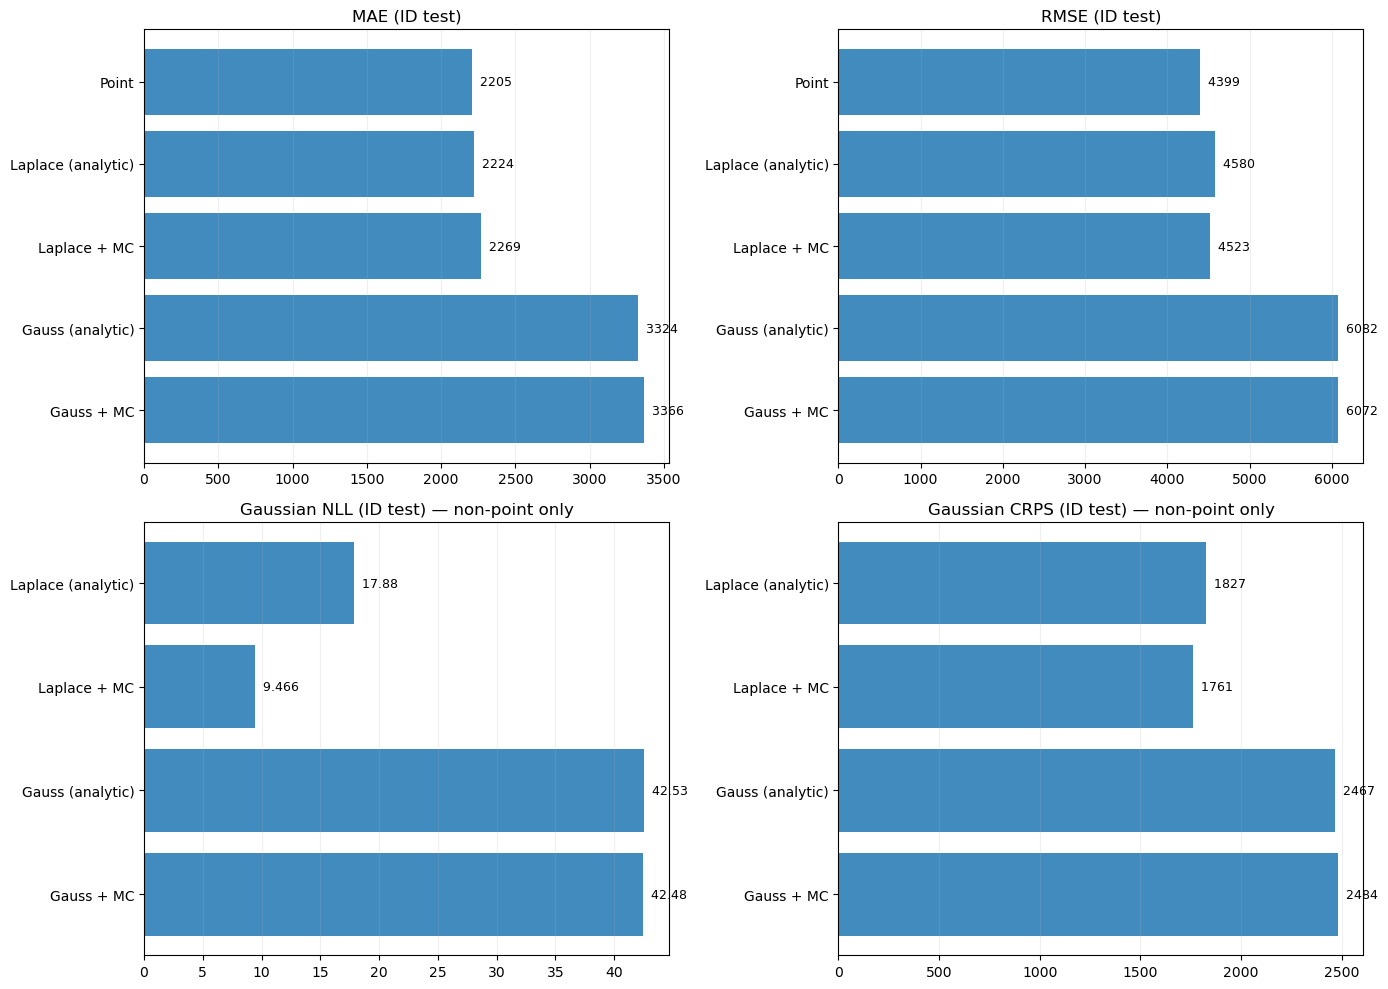

In [10]:
# Visualize core ID-test metrics from df_core_metrics.
# Note: point baseline is included for MAE/RMSE, but excluded from probabilistic metrics (NLL/CRPS).

import numpy as np
import matplotlib.pyplot as plt

dfm = df_core_metrics.copy()

# Consistent ordering (best-to-worst by MAE)
method_order = dfm.sort_values("MAE")["method"].tolist()

def _barh(ax, df, metric, title):
    sub = df.set_index("method").reindex(method_order).reset_index()
    sub = sub[np.isfinite(sub[metric].to_numpy(float))]
    if sub.empty:
        ax.set_axis_off()
        ax.set_title(f"{title} (no data)")
        return

    y = np.arange(len(sub))
    vals = sub[metric].to_numpy(float)

    ax.barh(y, vals, color="tab:blue", alpha=0.85)
    ax.set_yticks(y)
    ax.set_yticklabels(sub["method"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.grid(True, axis="x", alpha=0.2)

    # annotate values
    for yi, v in zip(y, vals):
        ax.text(v, yi, f"  {v:.4g}", va="center", ha="left", fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Accuracy metrics (include point)
_barh(axes[0], dfm, "MAE", "MAE (ID test)")
_barh(axes[1], dfm, "RMSE", "RMSE (ID test)")

# Probabilistic metrics (exclude point implicitly via NaNs)
df_prob = dfm[dfm["head_type"] != "point"].copy()
_barh(axes[2], df_prob, "NLL", "Gaussian NLL (ID test) — non-point only")
_barh(axes[3], df_prob, "CRPS", "Gaussian CRPS (ID test) — non-point only")

plt.tight_layout()
plt.show()


In [11]:
# Compute core ID-test metrics (file-first).
# Produces a small summary table; does NOT build a giant df.
from scripts.uq_eval import gaussian_nll
from scipy.stats import norm
def gaussian_crps_mean(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> float:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y[mask]
    mu = mu[mask]
    sigma = sigma[mask]
    z = (y - mu) / sigma
    crps = sigma * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))
# Calibration maps (may be empty if calibration not run)
try:
    alpha
except NameError:
    alpha = {}
try:
    beta
except NameError:
    beta = {}
if not alpha:
    alpha_cfg = cfg.get("alpha", {})
    alpha = alpha_cfg if isinstance(alpha_cfg, dict) else {}
if not beta:
    beta_cfg = cfg.get("beta", {})
    beta = beta_cfg if isinstance(beta_cfg, dict) else {}
if not alpha and not beta:
    print("[info] No calibration parameters found; using raw sigmas (alpha=beta=1).")
def calibrated_sigmas(
    *,
    head_type: str,
    ale_src: str,
    epi_src: str,
    sigma_ale_raw: np.ndarray,
    sigma_epi_raw: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # If NF doesn't have its own alpha (no val flow files), fall back to analytic alpha.
    def _alpha_lookup(ht: str, asrc: str) -> float:
        if (ht, asrc) in alpha:
            return float(alpha[(ht, asrc)])
        if asrc == "nf" and (ht, "analytic") in alpha:
            return float(alpha[(ht, "analytic")])
        return 1.0
    a = _alpha_lookup(head_type, ale_src)
    b = float(beta.get((head_type, ale_src, epi_src), 1.0))
    s_a2 = a * (np.asarray(sigma_ale_raw, float) ** 2)
    s_e2 = b * (np.asarray(sigma_epi_raw, float) ** 2)
    s_a = np.sqrt(np.maximum(s_a2, 0.0))
    s_e = np.sqrt(np.maximum(s_e2, 0.0))
    s_t = np.sqrt(np.maximum(s_a2 + s_e2, 0.0))
    return s_a, s_e, s_t
def method_id_test_frame(spec: MethodSpec) -> pd.DataFrame:
    if spec.key == "point":
        return load_id_regression(RUN_DIRS["point"], split="test", variant="point")
    if spec.key.startswith("lpl_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["lpl"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["lpl"], split="test", variant="analytic")
    if spec.key.startswith("gau_"):
        if spec.epistemic_source == "mc":
            return load_id_regression(RUN_DIRS["gau"], split="test", variant="mc")
        return load_id_regression(RUN_DIRS["gau"], split="test", variant="analytic")
    if spec.epistemic_source == "ensemble":
        if spec.head_type == "laplace":
            return load_id_ensemble(RUN_DIRS["esm_lpl"], split="test")
        return load_id_ensemble(RUN_DIRS["esm_gau"], split="test")
    raise ValueError(f"Unhandled core spec: {spec}")
rows = []
for spec in METHODS_CORE:
    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    # Calibrated sigmas (point has NaNs -> treat as 0)
    if spec.head_type == "point":
        sigma_total = np.full_like(mu, np.nan, dtype=float)
        mae = float(np.mean(np.abs(y - mu)))
        rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
        rows.append({"method": spec.label, "n": int(len(df)), "MAE": mae, "RMSE": rmse, "NLL": np.nan, "CRPS": np.nan, "mean_sigma_total": np.nan})
        continue
    s_a, s_e, s_t = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )
    mae = float(np.mean(np.abs(y - mu)))
    rmse = float(np.sqrt(np.mean((y - mu) ** 2)))
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(s_t) & (s_t > 0)
    nll = float(gaussian_nll(y[mask], mu[mask], s_t[mask])) if np.any(mask) else float("nan")
    crps = gaussian_crps_mean(y, mu, s_t)
    rows.append(
        {
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": int(len(df)),
            "MAE": mae,
            "RMSE": rmse,
            "NLL": nll,
            "CRPS": crps,
            "mean_sigma_total": float(np.nanmean(s_t)) if np.any(np.isfinite(s_t)) else float("nan"),
        }
    )
df_core_metrics = pd.DataFrame(rows)
display(df_core_metrics)


,method,n,MAE,RMSE,NLL,CRPS,mean_sigma_total,head_type,aleatoric_source,epistemic_source
0,Point,25358,2205.017043,4399.471557,NaN,NaN,NaN,NaN,NaN,NaN
1,Laplace (analytic),25358,2224.162833,4579.754206,17.876024,1827.244724,1048.877370,laplace,analytic,none
2,Laplace + MC,25358,2269.473250,4522.580280,9.466221,1760.501725,3154.007241,laplace,analytic,mc
3,Gauss (analytic),25358,3323.739423,6082.072736,42.525833,2467.216061,4388.511459,gauss,analytic,none
4,Gauss + MC,25358,3365.720719,6072.013259,42.477619,2483.570554,4388.511475,gauss,analytic,mc


,method,cov_raw_10,cov_raw_20,cov_raw_30,cov_raw_40,cov_raw_50,cov_raw_60,cov_raw_70,cov_raw_80,cov_raw_90,cov_10,cov_20,cov_30,cov_40,cov_50,cov_60,cov_70,cov_80,cov_90,ece
0,Laplace (analytic),0.156755,0.312682,0.451573,0.567789,0.663656,0.741857,0.808068,0.865959,0.918921,0.052962,0.107185,0.162395,0.221863,0.283579,0.347780,0.417975,0.495031,0.589400,20.242571
1,Laplace + MC,0.175842,0.346005,0.496017,0.618503,0.714331,0.789258,0.849042,0.900110,0.940965,0.160344,0.317454,0.457016,0.570550,0.659713,0.733812,0.797460,0.855825,0.909023,10.679952
2,Gauss (analytic),0.192878,0.377238,0.540500,0.668507,0.766701,0.844112,0.897744,0.938363,0.968057,0.130570,0.257434,0.381181,0.499369,0.603202,0.693588,0.776284,0.847938,0.909496,6.656238
3,Gauss + MC,0.221823,0.420459,0.588098,0.717801,0.812051,0.878776,0.923022,0.954531,0.977325,0.124142,0.248639,0.366314,0.481426,0.591174,0.687160,0.769501,0.843324,0.909181,5.787347


,method,ece
0,Laplace (analytic),20.242571
1,Laplace + MC,10.679952
2,Gauss (analytic),6.656238
3,Gauss + MC,5.787347


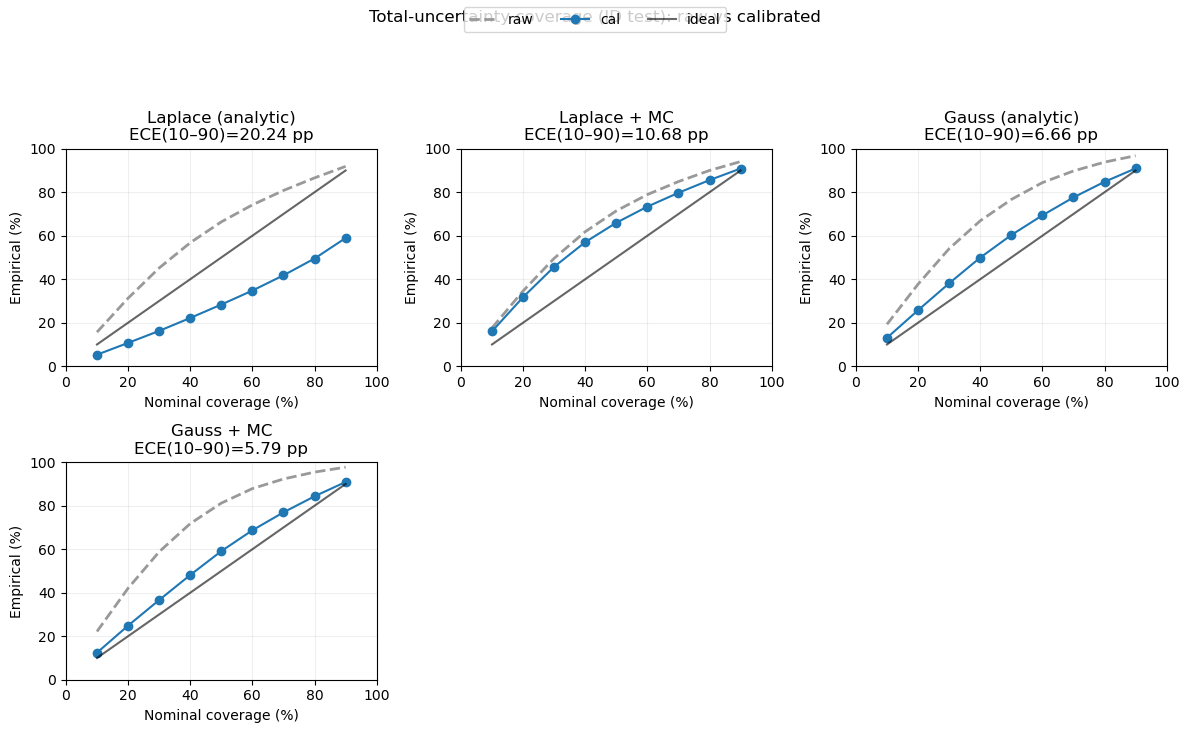

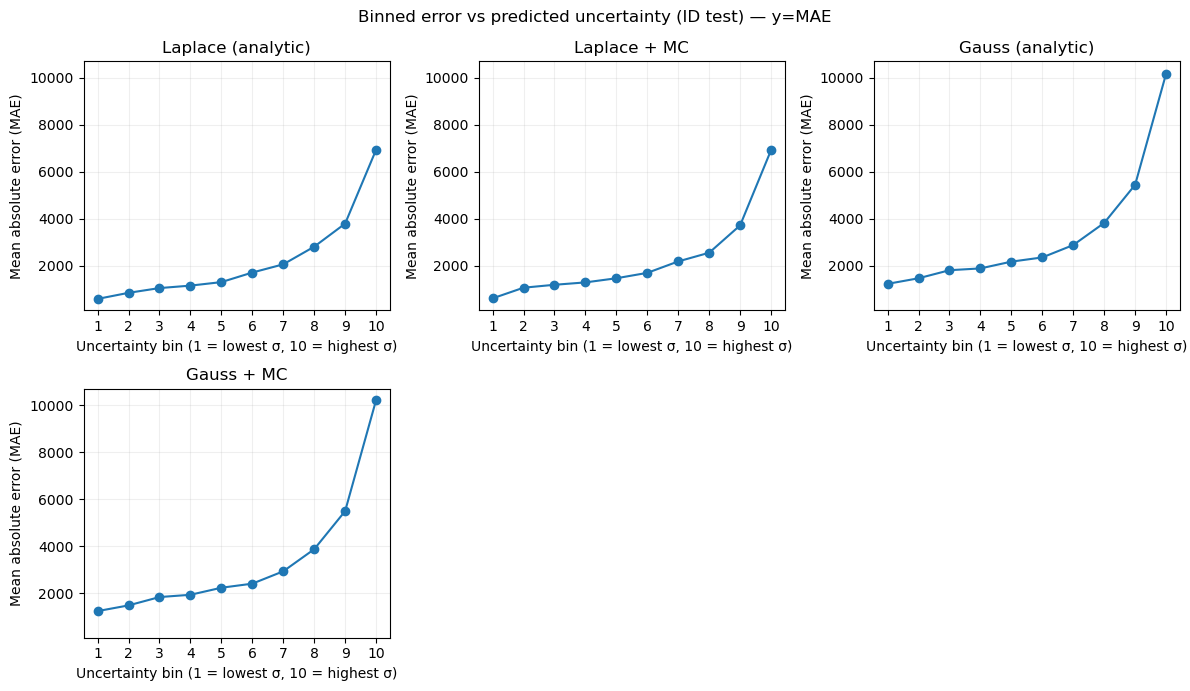

In [12]:
# Calibration diagnostics on ID test (core methods).
# - Coverage at 10–90% (step 10) + ECE (mean abs coverage error over 10–90, in percentage points)
# - Also plots "before calibration" (raw sigmas) as a grey dashed line.
# - Replaces the variance-vs-error² scatter with an intuitive binned plot:
#     bin by predicted uncertainty (σ_total), then plot mean MAE or mean CRPS per bin (toggle).
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
# Toggle for the binned plot y-axis:
BIN_METRIC = "mae"  # "mae" or "crps"
nominal_levels_plot = np.arange(10, 100, 10)  # 10..90
z_for_level = {lvl: float(norm.ppf((1 + (lvl / 100.0)) / 2.0)) for lvl in nominal_levels_plot}
def compute_coverage_points(y: np.ndarray, mu: np.ndarray, sigma_total: np.ndarray, levels, z_map):
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma_total = np.asarray(sigma_total, float)
    err = np.abs(y - mu)
    out = {}
    mask_base = np.isfinite(err) & np.isfinite(sigma_total) & (sigma_total > 0)
    for lvl in levels:
        z = z_map[lvl]
        out[lvl] = float(np.mean(err[mask_base] <= z * sigma_total[mask_base])) if np.any(mask_base) else float("nan")
    return out
def gaussian_crps_per_row(y: np.ndarray, mu: np.ndarray, sigma: np.ndarray) -> np.ndarray:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma = np.asarray(sigma, float)
    out = np.full_like(y, np.nan, dtype=float)
    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return out
    yy = y[mask]
    mm = mu[mask]
    ss = np.clip(sigma[mask], 1e-8, None)
    z = (yy - mm) / ss
    crps = ss * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    out[mask] = crps
    return out
def compute_bins_and_means(
    y: np.ndarray, mu: np.ndarray, sigma_total: np.ndarray, *, n_bins: int
) -> pd.DataFrame:
    y = np.asarray(y, float)
    mu = np.asarray(mu, float)
    sigma_total = np.asarray(sigma_total, float)
    abs_err = np.abs(y - mu)
    crps = gaussian_crps_per_row(y, mu, sigma_total)
    mask = np.isfinite(sigma_total) & (sigma_total > 0) & np.isfinite(abs_err)
    if not np.any(mask):
        return pd.DataFrame(columns=["bin", "bin_sigma_mean", "bin_mae_mean", "bin_crps_mean", "n"])
    s = sigma_total[mask]
    ae = abs_err[mask]
    cr = crps[mask]
    # Equal-count bins by predicted σ (more intuitive than variance)
    bins = pd.qcut(s, n_bins, labels=False, duplicates="drop")
    df = pd.DataFrame({"bin": bins.astype(int) + 1, "sigma": s, "abs_err": ae, "crps": cr})
    out = (
        df.groupby("bin")
        .agg(
            bin_sigma_mean=("sigma", "mean"),
            bin_mae_mean=("abs_err", "mean"),
            bin_crps_mean=("crps", "mean"),
            n=("abs_err", "size"),
        )
        .reset_index()
        .sort_values("bin")
        .reset_index(drop=True)
    )
    return out
coverage_rows = []
ece_rows = []
bins_rows = []
for spec in METHODS_CORE:
    if spec.head_type == "point":
        continue
    df = method_id_test_frame(spec)
    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    # Raw total sigma (no alpha/beta)
    s_raw = np.sqrt(
        np.maximum(
            np.nan_to_num(sigma_ale_raw, nan=0.0) ** 2 + np.nan_to_num(sigma_epi_raw, nan=0.0) ** 2,
            0.0,
        )
    )
    # Calibrated total sigma
    _, _, s_cal = calibrated_sigmas(
        head_type=spec.head_type,
        ale_src=spec.aleatoric_source,
        epi_src=spec.epistemic_source,
        sigma_ale_raw=sigma_ale_raw,
        sigma_epi_raw=sigma_epi_raw,
    )
    cov_raw = compute_coverage_points(y, mu, s_raw, nominal_levels_plot, z_for_level)
    cov_cal = compute_coverage_points(y, mu, s_cal, nominal_levels_plot, z_for_level)
    # ECE over 10–90 as mean abs coverage error in percentage points
    diffs = [abs(cov_cal[lvl] - (lvl / 100.0)) for lvl in nominal_levels_plot]
    diffs = [d for d in diffs if np.isfinite(d)]
    ece_pp = float(100.0 * np.mean(diffs)) if diffs else float("nan")
    coverage_rows.append(
        {
            "method": spec.label,
            **{f"cov_raw_{lvl}": cov_raw[lvl] for lvl in nominal_levels_plot},
            **{f"cov_{lvl}": cov_cal[lvl] for lvl in nominal_levels_plot},
            "ece": ece_pp,  # percent points
        }
    )
    ece_rows.append({"method": spec.label, "ece": ece_pp})
    # Bins for the option-2 plot (bin by calibrated σ_total)
    bdf = compute_bins_and_means(y, mu, s_cal, n_bins=N_RELIABILITY_BINS)
    bdf["method"] = spec.label
    bins_rows.append(bdf)
df_core_coverage = pd.DataFrame(coverage_rows)
df_cal_error = pd.DataFrame(ece_rows)
bins_rows = [b for b in bins_rows if not b.empty]
df_bins = pd.concat(bins_rows, ignore_index=True) if bins_rows else pd.DataFrame()
display(df_core_coverage)
display(df_cal_error)
# --- Coverage subplots (10-90%), with ECE in title and raw-vs-cal curves ---
methods_order = [m for m in df_core_coverage["method"] if "point" not in m.lower()]
n_methods = len(methods_order)
ncols = 3
nrows = int(np.ceil(n_methods / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
axes = axes.flatten()
for ax, method in zip(axes, methods_order):
    row = df_core_coverage[df_core_coverage["method"] == method].iloc[0]
    ece_pp = float(row["ece"])
    cov_cal = [row[f"cov_{lvl}"] * 100 for lvl in nominal_levels_plot]
    cov_raw = [row[f"cov_raw_{lvl}"] * 100 for lvl in nominal_levels_plot]
    ax.plot(nominal_levels_plot, cov_raw, "--", color="0.6", linewidth=2.0, label="raw")
    ax.plot(nominal_levels_plot, cov_cal, "-o", color="tab:blue", label="cal")
    ax.plot(nominal_levels_plot, nominal_levels_plot, "k-", alpha=0.6, label="ideal")
    ax.set_title(f"{method}\nECE(10–90)={ece_pp:.2f} pp")
    ax.set_xlabel("Nominal coverage (%)")
    ax.set_ylabel("Empirical (%)")
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.2)
for ax in axes[len(methods_order):]:
    ax.set_axis_off()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)
fig.suptitle("Total-uncertainty coverage (ID test): raw vs calibrated", y=1.04)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
# --- Option 2 (requested): binned mean error vs uncertainty bin (toggle MAE/CRPS) ---
metric_key = str(BIN_METRIC).strip().lower()
if metric_key not in {"mae", "crps"}:
    raise ValueError(f"BIN_METRIC must be 'mae' or 'crps', got {BIN_METRIC!r}")
y_col = "bin_mae_mean" if metric_key == "mae" else "bin_crps_mean"
y_label = "Mean absolute error (MAE)" if metric_key == "mae" else "Mean Gaussian CRPS"
y_vals = df_bins[y_col].to_numpy(float)
y_vals = y_vals[np.isfinite(y_vals)]
y_min, y_max = float(np.min(y_vals)), float(np.max(y_vals))
pad = 0.05 * (y_max - y_min) if y_max > y_min else 1.0
y_lim = (y_min - pad, y_max + pad)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), sharex=False, sharey=False)
axes = axes.flatten()
for ax, method in zip(axes, methods_order):
    sub = df_bins[df_bins["method"] == method].copy()
    if sub.empty:
        ax.set_axis_off()
        continue
    ax.plot(sub["bin"], sub[y_col], "-o", color="tab:blue")
    ax.set_ylim(*y_lim)
    ax.set_title(method)
    ax.set_xlabel("Uncertainty bin (1 = lowest σ, 10 = highest σ)")
    ax.set_ylabel(y_label)
    ax.set_xticks(np.arange(1, N_RELIABILITY_BINS + 1))
    ax.grid(True, alpha=0.2)
for ax in axes[len(methods_order):]:
    ax.set_axis_off()
fig.suptitle(f"Binned error vs predicted uncertainty (ID test) — y={metric_key.upper()}", y=0.98)
fig.tight_layout()
plt.show()


In [13]:
# --- OOD: file-first loading (memory efficient) ---
# Loads ONE (method, OOD split) CSV at a time and immediately reduces it to a small summary row.
# Also exposes `method_ood_frame(...)` for on-demand loading later (no global concat).

import numpy as np
import pandas as pd
from pathlib import Path

def load_ood_ensemble(run_dir: Path, label: str) -> pd.DataFrame:
    run_dir = Path(run_dir)
    candidates = [
        run_dir / f"ensemble_preds_ood_{label}.csv",  # <-- actual files
        run_dir / f"ensemble_ood_{label}.csv",
        run_dir / f"ood_{label}_test.csv",
    ]
    path = next((p for p in candidates if p.exists()), candidates[0])
    if not path.exists():
        raise FileNotFoundError(f"Ensemble OOD file not found for {label} under {run_dir}")

    df = _read_csv_usecols(
        path,
        [
            "id", "split", "head_type", "y_true",
            "y_pred_ens_mean", "sigma_ale_ens", "sigma_epi_ens",
            "y_pred_mean", "y_pred_method",
            "sigma_ale_orig", "sigma_epi_orig",
        ],
    )

    # Standardize prediction -> mu
    if "y_pred_ens_mean" in df.columns:
        df = df.rename(columns={"y_pred_ens_mean": "mu"})
    elif "y_pred_mean" in df.columns:
        df = df.rename(columns={"y_pred_mean": "mu"})
    elif "y_pred_method" in df.columns:
        df = df.rename(columns={"y_pred_method": "mu"})
    else:
        df["mu"] = np.nan

    # Standardize sigmas
    if "sigma_ale_ens" in df.columns:
        df = df.rename(columns={"sigma_ale_ens": "sigma_ale_raw"})
    elif "sigma_ale_orig" in df.columns:
        df = df.rename(columns={"sigma_ale_orig": "sigma_ale_raw"})
    else:
        df["sigma_ale_raw"] = np.nan

    if "sigma_epi_ens" in df.columns:
        df = df.rename(columns={"sigma_epi_ens": "sigma_epi_raw"})
    elif "sigma_epi_orig" in df.columns:
        df = df.rename(columns={"sigma_epi_orig": "sigma_epi_raw"})
    else:
        df["sigma_epi_raw"] = np.nan

    return df


def method_ood_frame(spec: MethodSpec, label: str) -> pd.DataFrame:
    # Map MethodSpec -> (run_dir, loader, variant)
    if spec.key == "point":
        run_dir = RUN_DIRS.get("point")
        if run_dir is None:
            raise FileNotFoundError("No point eval dir found")
        return load_ood_regression(run_dir, label, variant=None)

    if spec.key.startswith("lpl_"):
        run_dir = RUN_DIRS.get("lpl")
        if run_dir is None:
            raise FileNotFoundError("No lpl eval dir found")
        variant = "mc" if spec.epistemic_source == "mc" else None
        return load_ood_regression(run_dir, label, variant=variant)

    if spec.key.startswith("gau_"):
        run_dir = RUN_DIRS.get("gau")
        if run_dir is None:
            raise FileNotFoundError("No gau eval dir found")
        variant = "mc" if spec.epistemic_source == "mc" else None
        return load_ood_regression(run_dir, label, variant=variant)

    if spec.epistemic_source == "ensemble":
        ens_dir = RUN_DIRS.get("esm_lpl") if spec.head_type == "laplace" else RUN_DIRS.get("esm_gau")
        if ens_dir is None:
            raise FileNotFoundError("No ensemble eval dir found")
        return load_ood_ensemble(ens_dir, label)

    raise ValueError(f"Unhandled OOD spec: {spec}")


# Build a SMALL index table (one row per method×OOD split), without keeping any big frames in memory.
ood_rows = []
for ood_label in OOD_LABELS:
    for spec in METHODS_CORE:
        try:
            df = method_ood_frame(spec, ood_label)
        except FileNotFoundError:
            continue
        except Exception as e:
            print(f"[skip] {spec.key} / ood={ood_label}: {type(e).__name__}: {e}")
            continue

        y = df.get("y_true", pd.Series(np.nan, index=df.index)).to_numpy(float)
        mu = df.get("mu", pd.Series(np.nan, index=df.index)).to_numpy(float)
        n = int(len(df))

        row = {
            "ood_label": ood_label,
            "method": spec.label,
            "head_type": spec.head_type,
            "aleatoric_source": spec.aleatoric_source,
            "epistemic_source": spec.epistemic_source,
            "n": n,
            "mae": float(np.nanmean(np.abs(y - mu))) if n else float("nan"),
            "rmse": float(np.sqrt(np.nanmean((y - mu) ** 2))) if n else float("nan"),
        }

        if spec.head_type != "point":
            sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
            sigma_epi_raw = (
                df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
            )
            s_a, s_e, s_t = calibrated_sigmas(
                head_type=spec.head_type,
                ale_src=spec.aleatoric_source,
                epi_src=spec.epistemic_source,
                sigma_ale_raw=sigma_ale_raw,
                sigma_epi_raw=sigma_epi_raw,
            )
            row.update(
                {
                    "mean_Ua": float(np.nanmean(s_a)),
                    "mean_Ue": float(np.nanmean(s_e)),
                    "mean_Utot": float(np.nanmean(s_t)),
                }
            )

        ood_rows.append(row)
        del df  # ensure we don't accidentally retain frames

df_ood_index = pd.DataFrame(ood_rows).sort_values(["ood_label", "mae"], ascending=[True, True]).reset_index(drop=True)
display(df_ood_index)


,ood_label,method,head_type,aleatoric_source,epistemic_source,n,mae,rmse,mean_Ua,mean_Ue,mean_Utot
0,knn_hard,Laplace (analytic),laplace,analytic,none,1585,5341.725895,9091.060972,1360.992007,0.0,1360.992007
1,knn_hard,Point,point,none,none,1585,5349.239090,8824.389894,NaN,NaN,NaN
2,knn_hard,Gauss (analytic),gauss,analytic,none,1585,6146.821281,10511.414911,5047.170270,0.0,5047.170270


[skip] lpl_mc / ood:knn_hard: FileNotFoundError: [Errno 2] No such file or directory: '/home/canelo/uncertainty_quantification/outputs/evals/lpl_l_20251220-010458_303655/mc_preds_ood_knn_hard.csv'
[skip] gau_mc / ood:knn_hard: FileNotFoundError: [Errno 2] No such file or directory: '/home/canelo/uncertainty_quantification/outputs/evals/gau_l_20251220-013128_303690/mc_preds_ood_knn_hard.csv'


,dataset,method,spec_key,head_type,aleatoric_source,epistemic_source,n,Ua_mean,Ua_median,Ua_q10,Ua_q90,Ue_mean,Ue_median,Ue_q10,Ue_q90,Utot_mean,Utot_median,Utot_q10,Utot_q90,Ua_mean_id,Ue_mean_id,Utot_mean_id,Ua_mean_ratio_vs_id,Ua_mean_log2ratio_vs_id,Ue_mean_ratio_vs_id,Ue_mean_log2ratio_vs_id,Utot_mean_ratio_vs_id,Utot_mean_log2ratio_vs_id
0,id,Gauss + MC,gau_mc,gauss,analytic,mc,25358,6598.872216,5342.989502,2497.712256,11706.788770,3462.302301,3142.093872,1216.764709,5990.678760,7571.900333,6412.451412,2851.321719,13171.095389,6598.872216,3462.302301,7571.900333,1.0,0.0,1.0,0.0,1.0,0.0
1,id,Laplace + MC,lpl_mc,laplace,analytic,mc,25358,3109.664994,2092.679199,1256.997473,6006.509912,1858.145535,1306.052368,805.592255,3442.461304,3653.122835,2485.145886,1540.105572,6939.503289,3109.664994,1858.145535,3653.122835,1.0,0.0,1.0,0.0,1.0,0.0


dataset
method


dataset
method


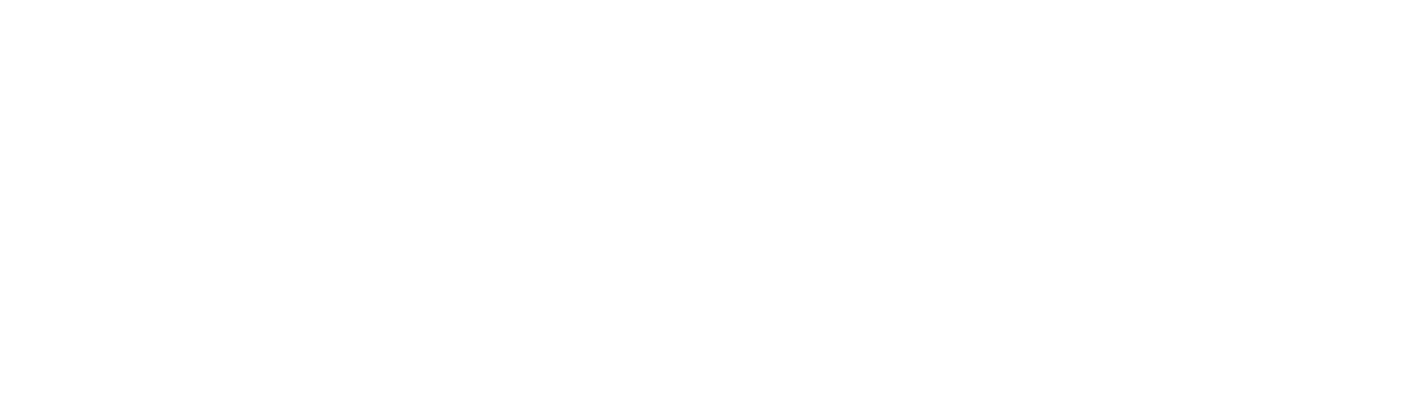

In [14]:

# --- Cell A: ID→OOD shift in Ua vs Ue (file-first, memory efficient) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INCLUDE_ALEATORIC_ONLY_BASELINES = False  # set True to include analytic-only methods (Ua only) in tables
USE_CALIBRATED_SIGMAS = False  # True = alpha/beta calibrated; False = raw sigma_ale_raw/sigma_epi_raw

def _has_epistemic(spec: MethodSpec) -> bool:
    return str(spec.epistemic_source).lower() in {"mc", "ensemble", "dido"}

def _summary(x: np.ndarray) -> dict:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"mean": np.nan, "median": np.nan, "q10": np.nan, "q90": np.nan}
    return {
        "mean": float(np.mean(x)),
        "median": float(np.median(x)),
        "q10": float(np.quantile(x, 0.10)),
        "q90": float(np.quantile(x, 0.90)),
    }

# Methods to analyze for decomposition shift:
methods_shift = []
methods_ale_only = []
for spec in METHODS_CORE:
    if spec.head_type == "point":
        continue
    if _has_epistemic(spec):
        methods_shift.append(spec)
    else:
        methods_ale_only.append(spec)

if INCLUDE_ALEATORIC_ONLY_BASELINES:
    methods_used = methods_shift + methods_ale_only
else:
    methods_used = methods_shift

rows = []
datasets = [("id", None)] + [(f"ood:{lbl}", lbl) for lbl in OOD_LABELS]

for spec in methods_used:
    for dataset_name, ood_label in datasets:
        try:
            df = method_id_test_frame(spec) if dataset_name == "id" else method_ood_frame(spec, ood_label)
        except Exception as e:
            print(f"[skip] {spec.key} / {dataset_name}: {type(e).__name__}: {e}")
            continue

        sigma_ale_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
        sigma_epi_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

        if USE_CALIBRATED_SIGMAS:
            s_a, s_e, s_t = calibrated_sigmas(
                head_type=spec.head_type,
                ale_src=spec.aleatoric_source,
                epi_src=spec.epistemic_source,
                sigma_ale_raw=sigma_ale_raw,
                sigma_epi_raw=sigma_epi_raw,
            )
        else:
            s_a = np.asarray(sigma_ale_raw, float)
            s_e = np.asarray(sigma_epi_raw, float)
            s_t = np.sqrt(
                np.maximum(
                    np.nan_to_num(s_a, nan=0.0) ** 2 + np.nan_to_num(s_e, nan=0.0) ** 2,
                    0.0,
                )
            )

        sa = _summary(s_a)
        se = _summary(s_e)
        st = _summary(s_t)

        rows.append(
            {
                "dataset": dataset_name,
                "method": spec.label,
                "spec_key": spec.key,
                "head_type": spec.head_type,
                "aleatoric_source": spec.aleatoric_source,
                "epistemic_source": spec.epistemic_source,
                "n": int(len(df)),
                "Ua_mean": sa["mean"],
                "Ua_median": sa["median"],
                "Ua_q10": sa["q10"],
                "Ua_q90": sa["q90"],
                "Ue_mean": se["mean"],
                "Ue_median": se["median"],
                "Ue_q10": se["q10"],
                "Ue_q90": se["q90"],
                "Utot_mean": st["mean"],
                "Utot_median": st["median"],
                "Utot_q10": st["q10"],
                "Utot_q90": st["q90"],
            }
        )

        del df  # don't retain frames

df_shift = pd.DataFrame(rows)
if df_shift.empty:
    raise RuntimeError("No OOD/ID rows loaded; check RUN_DIRS and eval filenames.")

# Ratios vs ID (per method)
id_ref = df_shift[df_shift["dataset"] == "id"]["""method Ua_mean Ue_mean Utot_mean""".split()].rename(
    columns={"Ua_mean": "Ua_mean_id", "Ue_mean": "Ue_mean_id", "Utot_mean": "Utot_mean_id"}
)
df_shift = df_shift.merge(id_ref, on="method", how="left")
for k in ["Ua_mean", "Ue_mean", "Utot_mean"]:
    df_shift[f"{k}_ratio_vs_id"] = df_shift[k] / df_shift[f"{k}_id"]
    df_shift[f"{k}_log2ratio_vs_id"] = np.log2(df_shift[f"{k}_ratio_vs_id"].to_numpy(float))

display(df_shift.sort_values(["method", "dataset"]).reset_index(drop=True))

# Compact “shift tables” (OOD only)
df_ood_shift = df_shift[df_shift["dataset"] != "id"].copy()

pivot_ue = df_ood_shift.pivot(index="method", columns="dataset", values="Ue_mean_log2ratio_vs_id")
pivot_ua = df_ood_shift.pivot(index="method", columns="dataset", values="Ua_mean_log2ratio_vs_id")
display(pivot_ue)
display(pivot_ua)

# Optional: quick heatmaps (log2 ratio vs ID)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

for ax, mat, title in [
    (axes[0], pivot_ue, "Epistemic shift: log2(mean Ue OOD / ID)"),
    (axes[1], pivot_ua, "Aleatoric shift: log2(mean Ua OOD / ID)"),
]:
    if mat.empty:
        ax.set_axis_off()
        continue
    im = ax.imshow(mat.to_numpy(float), aspect="auto", interpolation="nearest", cmap="coolwarm", vmin=-2, vmax=2)
    ax.set_title(title)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index.tolist())
    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns.tolist(), rotation=45, ha="right")
    plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)

plt.show()


In [15]:
# --- kNN split reaction + decoupling check (ID-in vs knn_mild/hard; within-test stratification) ---

import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# Toggle: use calibrated_sigmas(...) vs raw sigma_ale_raw/sigma_epi_raw
USE_CALIBRATED_SIGMAS_LOCAL = False

KNN_DIR = PROJECT_ROOT / "datasets" / "knn_ood"
KNN_FILES = {
    "knn_in":   KNN_DIR / "craigslist_id_knn_in.csv",
    "knn_mild": KNN_DIR / "craigslist_ood_knn_mild.csv",
    "knn_hard": KNN_DIR / "craigslist_ood_knn_hard.csv",
}

def _read_knn_ids_and_scores(path):
    df = pd.read_csv(path, usecols=["id", "knn_score"])
    df["id_str"] = df["id"].astype(str)
    df["knn_score"] = df["knn_score"].astype(float)
    return df[["id_str", "knn_score"]]

knn_split = {}
for name, path in KNN_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing kNN split CSV: {path}")
    knn_split[name] = _read_knn_ids_and_scores(path)

# Map id -> knn_score for the *entire* test partition (in+mild+hard)
df_knn_all = pd.concat(list(knn_split.values()), axis=0, ignore_index=True)
knn_score_map = dict(zip(df_knn_all["id_str"].to_list(), df_knn_all["knn_score"].to_list()))
split_ids = {k: set(v["id_str"].to_list()) for k, v in knn_split.items()}

print("kNN split sizes:", {k: len(v) for k, v in split_ids.items()})
print("pairwise overlaps:",
      {f"{a}∩{b}": len(split_ids[a] & split_ids[b]) for a in split_ids for b in split_ids if a < b})

def _sigmas_for(spec, df):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(
            np.maximum(
                np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2,
                0.0,
            )
        )
    return sA, sE, sT

def _safe_auc(y_true, score, *, kind="auroc"):
    y_true = np.asarray(y_true, int)
    score = np.asarray(score, float)
    m = np.isfinite(score)
    y_true = y_true[m]
    score = score[m]
    if y_true.size == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    if kind == "auroc":
        return float(roc_auc_score(y_true, score))
    if kind == "auprc":
        return float(average_precision_score(y_true, score))
    raise ValueError(kind)

# Only the two MC methods you care about
SPECS = [s for s in METHODS_CORE if s.key in {"gau_mc", "lpl_mc"}]

rows_summary = []
rows_det = []

for spec in SPECS:
    df = method_id_test_frame(spec).copy()
    df["id_str"] = df["id"].astype(str)
    df["knn_score"] = df["id_str"].map(knn_score_map)

    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    ae = np.abs(y - mu)

    sA, sE, sT = _sigmas_for(spec, df)

    # Coverage sanity: do we have knn_score for all test rows?
    miss_knn = float(pd.isna(df["knn_score"]).mean())
    print(f"\n[{spec.label}] knn_score missing fraction on id:test = {miss_knn:.4f}")

    # Split-level summaries (ID baseline = knn_in, non-overlapping)
    for name in ["knn_in", "knn_mild", "knn_hard"]:
        m = df["id_str"].isin(split_ids[name]).to_numpy()
        rows_summary.append(
            {
                "method": spec.label,
                "split": name,
                "n": int(m.sum()),
                "mae": float(np.nanmean(ae[m])),
                "Ua_mean": float(np.nanmean(sA[m])),
                "Ue_mean": float(np.nanmean(sE[m])),
                "Utot_mean": float(np.nanmean(sT[m])),
            }
        )

    # OOD detection: knn_in vs each OOD (clean baseline)
    for ood in ["knn_mild", "knn_hard"]:
        m_id = df["id_str"].isin(split_ids["knn_in"]).to_numpy()
        m_ood = df["id_str"].isin(split_ids[ood]).to_numpy()
        y_ood = np.concatenate([np.zeros(m_id.sum(), int), np.ones(m_ood.sum(), int)], axis=0)

        for score_name, score_arr in [("Ua", sA), ("Ue", sE), ("Utot", sT)]:
            score = np.concatenate([score_arr[m_id], score_arr[m_ood]], axis=0)
            rows_det.append(
                {
                    "method": spec.label,
                    "ood": ood,
                    "score": score_name,
                    "ooddet_auroc": _safe_auc(y_ood, score, kind="auroc"),
                    "ooddet_auprc": _safe_auc(y_ood, score, kind="auprc"),
                }
            )

    # Large-error detection inside each split (uses LARGE_ERROR_TAU from Cell 4)
    for name in ["knn_in", "knn_mild", "knn_hard"]:
        m = df["id_str"].isin(split_ids[name]).to_numpy()
        y_large = (ae[m] >= LARGE_ERROR_TAU).astype(int)
        for score_name, score_arr in [("Ua", sA), ("Ue", sE), ("Utot", sT)]:
            rows_det.append(
                {
                    "method": spec.label,
                    "ood": name,
                    "score": score_name,
                    "largeerr_auroc": _safe_auc(y_large, score_arr[m], kind="auroc"),
                    "largeerr_auprc": _safe_auc(y_large, score_arr[m], kind="auprc"),
                }
            )

    # Within-test monotonicity: how do uncertainties track knn_score?
    m = np.isfinite(df["knn_score"].to_numpy(float)) & np.isfinite(ae)
    ks = df.loc[m, "knn_score"].to_numpy(float)

    print(f"[{spec.label}] Spearman corr(knn_score, Ua) = {spearmanr(ks, sA[m]).correlation:.3f}")
    print(f"[{spec.label}] Spearman corr(knn_score, Ue) = {spearmanr(ks, sE[m]).correlation:.3f}")
    print(f"[{spec.label}] Spearman corr(knn_score, |err|) = {spearmanr(ks, ae[m]).correlation:.3f}")

    # Bin plot
    tmp = pd.DataFrame(
        {"knn_score": ks, "Ua": sA[m], "Ue": sE[m], "Utot": sT[m], "ae": ae[m]}
    ).dropna()
    tmp["bin"] = pd.qcut(tmp["knn_score"], q=10, labels=False, duplicates="drop") + 1
    g = tmp.groupby("bin").agg(
        knn_mean=("knn_score", "mean"),
        Ua_mean=("Ua", "mean"),
        Ue_mean=("Ue", "mean"),
        Utot_mean=("Utot", "mean"),
        ae_mean=("ae", "mean"),
        n=("ae", "size"),
    ).reset_index()

    fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))
    ax1.plot(g["bin"], g["Ua_mean"], marker="o", label="Ua mean")
    ax1.plot(g["bin"], g["Ue_mean"], marker="o", label="Ue mean")
    ax1.plot(g["bin"], g["Utot_mean"], marker="o", label="Utot mean")
    ax1.set_xlabel("knn_score decile (low→high)")
    ax1.set_ylabel("mean uncertainty (sigma)")
    ax2 = ax1.twinx()
    ax2.plot(g["bin"], g["ae_mean"], marker="s", color="black", label="|err| mean")
    ax2.set_ylabel("mean |err|")
    ax1.set_title(f"{spec.label}: uncertainty + error vs kNN distance decile")
    lines, labels = [], []
    for a in [ax1, ax2]:
        l, lab = a.get_legend_handles_labels()
        lines += l; labels += lab
    ax1.legend(lines, labels, loc="upper left")
    plt.show()

df_knn_summary = pd.DataFrame(rows_summary)
display(df_knn_summary)

df_det = pd.DataFrame(rows_det)
display(df_det.sort_values(["method", "ood", "score"]).reset_index(drop=True))

# Quick AUROC pivot for OOD detection (knn_in vs knn_mild/hard)
df_ooddet = df_det.dropna(subset=["ooddet_auroc"]).copy()
if not df_ooddet.empty:
    p = df_ooddet.pivot_table(index=["method", "score"], columns="ood", values="ooddet_auroc", aggfunc="mean")
    display(p)

    # Bar chart: AUROC per (method, score) for knn_hard
    if "knn_hard" in p.columns:
        s = p["knn_hard"].sort_values()
        ax = s.plot(kind="barh", figsize=(8, 4), title="OOD detection AUROC (knn_in vs knn_hard)")
        ax.set_xlabel("AUROC")
        plt.tight_layout()
        plt.show()


FileNotFoundError: Missing kNN split CSV: /home/canelo/uncertainty_quantification/datasets/knn_ood/craigslist_id_knn_in.csv

In [ ]:
# --- Incremental value of Ue beyond Ua (fit on ID-val, evaluate on kNN splits) ---

import numpy as np
import pandas as pd

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.stats import spearmanr

EPS = 1e-8
USE_CALIBRATED_SIGMAS_LOCAL = False  # keep consistent with your previous cell

SPECS = [s for s in METHODS_CORE if s.key in {"gau_mc", "lpl_mc"}]

def _sigmas_for(spec, df):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED_SIGMAS_LOCAL:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _safe_metrics(y, s):
    y = np.asarray(y, int)
    s = np.asarray(s, float)
    m = np.isfinite(s)
    y = y[m]; s = s[m]
    if y.size == 0 or len(np.unique(y)) < 2:
        return np.nan, np.nan
    return float(roc_auc_score(y, s)), float(average_precision_score(y, s))

rows = []

for spec in SPECS:
    # ---- fit on ID-val ----
    dfv = load_id_regression(
        RUN_DIRS["gau"] if spec.key == "gau_mc" else RUN_DIRS["lpl"],
        split="val",
        variant="mc",
    ).copy()

    yv = dfv["y_true"].to_numpy(float)
    muv = dfv["mu"].to_numpy(float)
    aev = np.abs(yv - muv)
    y_large_v = (aev >= LARGE_ERROR_TAU).astype(int)

    sA_v, sE_v, sT_v = _sigmas_for(spec, dfv)

    Xv_ua = np.log(np.clip(sA_v, EPS, None)).reshape(-1, 1)
    Xv_ue = np.log(np.clip(sE_v, EPS, None)).reshape(-1, 1)
    Xv_both = np.concatenate([Xv_ua, Xv_ue], axis=1)

    clf_ua = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    clf_ue = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    clf_both = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))

    mfit_ua = np.isfinite(Xv_ua).all(axis=1) & np.isfinite(y_large_v)
    mfit_ue = np.isfinite(Xv_ue).all(axis=1) & np.isfinite(y_large_v)
    mfit_b = np.isfinite(Xv_both).all(axis=1) & np.isfinite(y_large_v)

    clf_ua.fit(Xv_ua[mfit_ua], y_large_v[mfit_ua])
    clf_ue.fit(Xv_ue[mfit_ue], y_large_v[mfit_ue])
    clf_both.fit(Xv_both[mfit_b], y_large_v[mfit_b])

    # quick “is Ue redundant?”: residualize log(Ue) on log(Ua) (val)
    lv_ua = Xv_ua[mfit_b, 0]
    lv_ue = Xv_ue[mfit_b, 0]
    A = np.vstack([np.ones_like(lv_ua), lv_ua]).T
    coef, *_ = np.linalg.lstsq(A, lv_ue, rcond=None)
    lv_ue_resid = lv_ue - (A @ coef)
    corr_resid = spearmanr(lv_ue_resid, y_large_v[mfit_b]).correlation

    rows.append({
        "method": spec.label,
        "fit_split": "id:val",
        "largeerr_prev": float(y_large_v.mean()),
        "resid_spearman(logUe~logUa, largeerr)": float(corr_resid),
    })

    # ---- evaluate on test kNN splits ----
    dft = method_id_test_frame(spec).copy()
    dft["id_str"] = dft["id"].astype(str)

    yt = dft["y_true"].to_numpy(float)
    mut = dft["mu"].to_numpy(float)
    aet = np.abs(yt - mut)
    y_large_t = (aet >= LARGE_ERROR_TAU).astype(int)

    sA_t, sE_t, sT_t = _sigmas_for(spec, dft)
    Xt_ua = np.log(np.clip(sA_t, EPS, None)).reshape(-1, 1)
    Xt_ue = np.log(np.clip(sE_t, EPS, None)).reshape(-1, 1)
    Xt_b = np.concatenate([Xt_ua, Xt_ue], axis=1)

    for split_name in ["knn_in", "knn_mild", "knn_hard"]:
        m = dft["id_str"].isin(split_ids[split_name]).to_numpy()

        # baselines
        auroc_ua, auprc_ua = _safe_metrics(y_large_t[m], sA_t[m])
        auroc_ue, auprc_ue = _safe_metrics(y_large_t[m], sE_t[m])
        auroc_ut, auprc_ut = _safe_metrics(y_large_t[m], sT_t[m])

        # learned combos (probabilities)
        p_ua = clf_ua.predict_proba(Xt_ua[m])[:, 1]
        p_ue = clf_ue.predict_proba(Xt_ue[m])[:, 1]
        p_b  = clf_both.predict_proba(Xt_b[m])[:, 1]

        auroc_pua, auprc_pua = _safe_metrics(y_large_t[m], p_ua)
        auroc_pue, auprc_pue = _safe_metrics(y_large_t[m], p_ue)
        auroc_pb,  auprc_pb  = _safe_metrics(y_large_t[m], p_b)

        rows.append({
            "method": spec.label,
            "eval_split": split_name,
            "n": int(m.sum()),
            "largeerr_prev": float(y_large_t[m].mean()),
            "AUROC(Ua)": auroc_ua,
            "AUROC(Ue)": auroc_ue,
            "AUROC(Utot)": auroc_ut,
            "AUROC(logit Ua)": auroc_pua,
            "AUROC(logit Ue)": auroc_pue,
            "AUROC(logit Ua+Ue)": auroc_pb,
            "AUPRC(Ua)": auprc_ua,
            "AUPRC(Ue)": auprc_ue,
            "AUPRC(Utot)": auprc_ut,
            "AUPRC(logit Ua+Ue)": auprc_pb,
        })

df_incr = pd.DataFrame(rows)
display(df_incr)


In [ ]:
STOP

In [ ]:
# --- Sanity checks: is epistemic present, and is calibration squashing it? ---

import numpy as np
import pandas as pd

# 1) Inspect fitted calibration params
print("alpha:")
for k, v in sorted(alpha.items()):
    print(" ", k, "=", v)

print("\nbeta:")
for k, v in sorted(beta.items()):
    print(" ", k, "=", v)

# 2) Pick a few representative method+OOD combos to inspect raw columns
CHECK_OOD = ["geo", "tail_multi"]  # adjust
CHECK_METHOD_KEYS = ["gau_mc", "esm_gau", "lpl_mc", "esm_lpl"]  # adjust

spec_by_key = {s.key: s for s in METHODS_CORE}

def _desc(x: np.ndarray) -> dict:
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return {"n": 0}
    qs = np.quantile(x, [0.0, 0.1, 0.5, 0.9, 1.0])
    return {
        "n": int(x.size),
        "min": float(qs[0]),
        "q10": float(qs[1]),
        "median": float(qs[2]),
        "q90": float(qs[3]),
        "max": float(qs[4]),
        "mean": float(np.mean(x)),
    }

rows = []
for ood_label in CHECK_OOD:
    for key in CHECK_METHOD_KEYS:
        spec = spec_by_key.get(key)
        if spec is None:
            print(f"[warn] Unknown method key: {key}")
            continue

        try:
            df = method_ood_frame(spec, ood_label)
        except Exception as e:
            print(f"[skip] {key} / ood={ood_label}: {type(e).__name__}: {e}")
            continue

        # raw columns as the notebook uses them
        sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
        sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)  # don't fill yet

        # what fraction is missing?
        miss_ale = float(np.mean(~np.isfinite(sA_raw)))
        miss_epi = float(np.mean(~np.isfinite(sE_raw)))

        # if epi is missing, you are effectively zeroing it later
        sE_raw_filled = np.nan_to_num(sE_raw, nan=0.0)

        # calibrated
        sA_cal, sE_cal, sT_cal = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw_filled,
        )

        rows.append(
            {
                "ood": ood_label,
                "method": spec.label,
                "key": key,
                "head_type": spec.head_type,
                "epi_src": spec.epistemic_source,
                "miss_sigma_ale_raw_frac": miss_ale,
                "miss_sigma_epi_raw_frac": miss_epi,
                **{f"raw_ale_{k}": v for k, v in _desc(sA_raw).items()},
                **{f"raw_epi_{k}": v for k, v in _desc(sE_raw).items()},
                **{f"cal_ale_{k}": v for k, v in _desc(sA_cal).items()},
                **{f"cal_epi_{k}": v for k, v in _desc(sE_cal).items()},
                "cal_mean_Ue_over_Ua": float(np.nanmean(sE_cal) / np.nanmean(sA_cal)) if np.isfinite(np.nanmean(sA_cal)) and np.nanmean(sA_cal) > 0 else np.nan,
            }
        )

        # quick column presence check
        print(f"\n[{key} / ood={ood_label}] columns present:")
        print("  has sigma_ale_raw:", "sigma_ale_raw" in df.columns)
        print("  has sigma_epi_raw:", "sigma_epi_raw" in df.columns)
        print("  example head:", df.head(2))

        del df

df_check = pd.DataFrame(rows)
print(df_check)

# 3) If you suspect Ue is tiny because of scaling, compare transformed-space uncertainty if available
# (This is only possible if your eval CSVs include *_orig columns or transformed-scale columns; otherwise skip.)


In [ ]:
# --- Diagnose why beta -> 1e-8: objective curves + epi usefulness on ID-val ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scripts.uq_eval import gaussian_nll

# Use the same objective as calibration cell
CALIB_OBJ = str(CALIBRATION_OBJECTIVE).strip().lower()

def gaussian_crps_mean(y_true, y_pred, sigma):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    sigma = np.asarray(sigma, float)
    mask = np.isfinite(y_true) & np.isfinite(y_pred) & np.isfinite(sigma) & (sigma > 0)
    if not np.any(mask):
        return float("nan")
    y = y_true[mask]
    m = y_pred[mask]
    s = np.clip(sigma[mask], 1e-8, None)
    z = (y - m) / s
    crps = s * (z * (2 * norm.cdf(z) - 1) + 2 * norm.pdf(z) - 1 / np.sqrt(np.pi))
    return float(np.mean(crps))

def _score(y, mu, sigma):
    if CALIB_OBJ == "nll":
        return float(gaussian_nll(y, mu, sigma))
    return float(gaussian_crps_mean(y, mu, sigma))

# Wide beta grid (include your floor)
BETA_GRID = np.logspace(-12, 3, 120)

def _diagnose_one(head_key, head_type, epi_kind: str):
    """
    epi_kind: "mc" or "ensemble"
    """
    a = float(alpha.get((head_type, "analytic"), 1.0))
    if epi_kind == "mc":
        df = load_id_regression(RUN_DIRS[head_key], split="val", variant="mc")
        spec_label = f"{head_type} / MC"
    else:
        ens_key = "esm_lpl" if head_type == "laplace" else "esm_gau"
        df = load_id_ensemble(RUN_DIRS[ens_key], split="val")
        spec_label = f"{head_type} / ensemble"

    y = df["y_true"].to_numpy(float)
    mu = df["mu"].to_numpy(float)
    sA = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

    mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sA) & np.isfinite(sE) & (sA >= 0) & (sE >= 0)
    y, mu, sA, sE = y[mask], mu[mask], sA[mask], sE[mask]

    # Baselines to interpret behavior
    sigma_ale_only = np.sqrt(np.maximum(a * sA**2, 1e-12))
    sigma_naive_sum = np.sqrt(np.maximum(a * sA**2 + 1.0 * sE**2, 1e-12))

    base_ale_score = _score(y, mu, sigma_ale_only)
    base_sum_score = _score(y, mu, sigma_naive_sum)

    scores = []
    for b in BETA_GRID:
        sigma_tot = np.sqrt(np.maximum(a * sA**2 + b * sE**2, 1e-12))
        scores.append(_score(y, mu, sigma_tot))
    scores = np.asarray(scores, float)

    best_i = int(np.nanargmin(scores))
    best_b = float(BETA_GRID[best_i])
    best_score = float(scores[best_i])

    # How correlated is epi with absolute error? (if weak/negative -> beta tends to 0 under proper score)
    ae = np.abs(y - mu)
    corr = np.corrcoef(ae, sE)[0, 1] if (np.std(ae) > 0 and np.std(sE) > 0) else np.nan

    out = {
        "label": spec_label,
        "n": int(y.size),
        "alpha_used": a,
        "score_ale_only(b=0)": base_ale_score,
        "score_sum(b=1)": base_sum_score,
        "best_beta": best_b,
        "best_score": best_score,
        "corr(|err|, sigma_epi_raw)": float(corr),
        "mean_sigma_ale_raw": float(np.mean(sA)),
        "mean_sigma_epi_raw": float(np.mean(sE)),
    }
    return out, scores

results = []
curves = {}

for head_key, head_type in [("lpl", "laplace"), ("gau", "gauss")]:
    if RUN_DIRS.get(head_key) is None:
        continue
    r_mc, c_mc = _diagnose_one(head_key, head_type, "mc")
    results.append(r_mc)
    curves[(head_type, "mc")] = c_mc

    ens_key = "esm_lpl" if head_type == "laplace" else "esm_gau"
    if RUN_DIRS.get(ens_key) is not None:
        r_ens, c_ens = _diagnose_one(head_key, head_type, "ensemble")
        results.append(r_ens)
        curves[(head_type, "ensemble")] = c_ens

df_beta_diag = pd.DataFrame(results)
display(df_beta_diag)

# Plot objective vs beta (log-x)
nplots = len(curves)
fig, axes = plt.subplots(1, nplots, figsize=(5.5 * nplots, 4), sharey=False)
axes = np.atleast_1d(axes)

for ax, ((head_type, epi_kind), scores) in zip(axes, curves.items()):
    ax.plot(BETA_GRID, scores, lw=2)
    ax.set_xscale("log")
    ax.set_title(f"{head_type} / {epi_kind} — {CALIB_OBJ.upper()} vs beta")
    ax.set_xlabel("beta (multiplier on sigma_epi_raw^2)")
    ax.set_ylabel(f"mean {CALIB_OBJ.upper()}")
    ax.grid(True, which="both", alpha=0.2)

    best_i = int(np.nanargmin(scores))
    ax.axvline(BETA_GRID[best_i], color="k", ls="--", alpha=0.7)
    ax.text(BETA_GRID[best_i], float(scores[best_i]), f"  best={BETA_GRID[best_i]:.1e}", va="center")

plt.tight_layout()
plt.show()

print(
    "\nInterpretation guide:\n"
    "- If the curve is minimized at the left edge (smallest beta), the scoring rule prefers ignoring sigma_epi_raw.\n"
    "- Common reasons: sigma_epi_raw is poorly correlated with error, too large/noisy, or double-counts uncertainty already in sigma_ale_raw.\n"
    "- Check corr(|err|, sigma_epi_raw) and compare score_ale_only vs score_sum(b=1)."
)


In [ ]:
# --- Diagnostic: does sigma_epi_raw add signal beyond sigma_ale_raw on ID-val? ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pick which family to diagnose
DIAG_HEAD = "gauss"      # "gauss" or "laplace"
DIAG_EPI  = "mc"         # "mc" or "ensemble"
N_BINS = 10

head_key = "gau" if DIAG_HEAD == "gauss" else "lpl"
head_type = DIAG_HEAD

a = float(alpha.get((head_type, "analytic"), 1.0))

if DIAG_EPI == "mc":
    df = load_id_regression(RUN_DIRS[head_key], split="val", variant="mc")
    label = f"{DIAG_HEAD} / MC"
else:
    ens_key = "esm_gau" if DIAG_HEAD == "gauss" else "esm_lpl"
    df = load_id_ensemble(RUN_DIRS[ens_key], split="val")
    label = f"{DIAG_HEAD} / ensemble"

y = df["y_true"].to_numpy(float)
mu = df["mu"].to_numpy(float)
sA = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
sE = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sA) & np.isfinite(sE) & (sA >= 0) & (sE >= 0)
y, mu, sA, sE = y[mask], mu[mask], sA[mask], sE[mask]

err = y - mu
err2 = err * err
ae = np.abs(err)

# Residual variance not explained by aleatoric (if model is calibrated, this should be ~ beta*sE^2 on avg)
resid2_minus_ale = err2 - a * (sA ** 2)

# 1) Bin by sigma_epi_raw and show how |err| and "excess err^2" behave
bins = pd.qcut(sE, N_BINS, labels=False, duplicates="drop")
bdf = pd.DataFrame(
    {
        "bin": bins.astype(int) + 1,
        "sigma_epi_raw": sE,
        "sigma_ale_raw": sA,
        "abs_err": ae,
        "err2": err2,
        "err2_minus_a_sA2": resid2_minus_ale,
    }
)

agg = (
    bdf.groupby("bin")
    .agg(
        n=("abs_err", "size"),
        epi_mean=("sigma_epi_raw", "mean"),
        ale_mean=("sigma_ale_raw", "mean"),
        abs_err_mean=("abs_err", "mean"),
        err2_mean=("err2", "mean"),
        err2_minus_a_sA2_mean=("err2_minus_a_sA2", "mean"),
        err2_minus_a_sA2_frac_pos=("err2_minus_a_sA2", lambda x: float(np.mean(np.asarray(x) > 0))),
    )
    .reset_index()
    .sort_values("bin")
)

display(agg)

fig, axes = plt.subplots(1, 3, figsize=(16, 4), constrained_layout=True)
axes[0].plot(agg["bin"], agg["abs_err_mean"], "-o")
axes[0].set_title(f"{label}: mean |err| vs epi-bin (ID-val)")
axes[0].set_xlabel("epi bin (low→high)")
axes[0].set_ylabel("mean |y-mu|")
axes[0].grid(True, alpha=0.2)

axes[1].plot(agg["bin"], agg["err2_minus_a_sA2_mean"], "-o")
axes[1].axhline(0, color="k", lw=1, alpha=0.6)
axes[1].set_title(f"{label}: mean(err^2 - a*sA^2) vs epi-bin (ID-val)")
axes[1].set_xlabel("epi bin (low→high)")
axes[1].set_ylabel("mean excess squared error")
axes[1].grid(True, alpha=0.2)

axes[2].plot(agg["bin"], agg["epi_mean"], "-o", label="mean sE")
axes[2].plot(agg["bin"], agg["ale_mean"], "-o", label="mean sA")
axes[2].set_title(f"{label}: mean sigma_raw per epi-bin (ID-val)")
axes[2].set_xlabel("epi bin (low→high)")
axes[2].set_ylabel("mean sigma")
axes[2].grid(True, alpha=0.2)
axes[2].legend()

plt.show()

# 2) Regression-style check: does sE^2 explain residual variance beyond a*sA^2?
# Fit c in: err2 ≈ a*sA^2 + c*sE^2 + intercept, with c constrained only by data (can be negative).
X = np.column_stack([np.ones_like(err2), a * (sA ** 2), (sE ** 2)])
# OLS
coef, *_ = np.linalg.lstsq(X, err2, rcond=None)
intercept, c_ale, c_epi = coef.tolist()

print(f"\n[{label}] OLS fit: err^2 ≈ intercept + c1*(a*sA^2) + c2*(sE^2)")
print(f"  intercept = {intercept:.3g}")
print(f"  c1 on a*sA^2 = {c_ale:.3g}  (should be ~1 if aleatoric scale matches)")
print(f"  c2 on sE^2   = {c_epi:.3g}  (if ~0 or negative, beta will be driven to 0)")

# Optional: correlation checks
def _corr(u, v):
    u = np.asarray(u, float); v = np.asarray(v, float)
    if np.std(u) < 1e-12 or np.std(v) < 1e-12:
        return np.nan
    return float(np.corrcoef(u, v)[0, 1])

print("\nCorrelations on ID-val:")
print("  corr(|err|, sA) =", _corr(ae, sA))
print("  corr(|err|, sE) =", _corr(ae, sE))
print("  corr(err^2 - a*sA^2, sE^2) =", _corr(resid2_minus_ale, sE**2))


In [ ]:
# --- Next: redundancy + ranking utility checks for sigma_epi_raw (ID-val) ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

DIAG_HEAD = "gauss"   # "gauss" or "laplace"
DIAG_EPI  = "mc"      # "mc" or "ensemble"
N_BINS = 10
LARGE_Q = LARGE_ERROR_QUANTILE  # uses your existing knob (0.90)

head_key = "gau" if DIAG_HEAD == "gauss" else "lpl"
head_type = DIAG_HEAD

# Load ID-val frame
if DIAG_EPI == "mc":
    df = load_id_regression(RUN_DIRS[head_key], split="val", variant="mc")
    label = f"{DIAG_HEAD} / MC"
else:
    ens_key = "esm_gau" if DIAG_HEAD == "gauss" else "esm_lpl"
    df = load_id_ensemble(RUN_DIRS[ens_key], split="val")
    label = f"{DIAG_HEAD} / ensemble"

y = df["y_true"].to_numpy(float)
mu = df["mu"].to_numpy(float)
sA = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
sE = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)

mask = np.isfinite(y) & np.isfinite(mu) & np.isfinite(sA) & np.isfinite(sE) & (sA >= 0) & (sE >= 0)
y, mu, sA, sE = y[mask], mu[mask], sA[mask], sE[mask]

ae = np.abs(y - mu)

def _corr(u, v):
    u = np.asarray(u, float); v = np.asarray(v, float)
    if np.std(u) < 1e-12 or np.std(v) < 1e-12:
        return np.nan
    return float(np.corrcoef(u, v)[0, 1])

print(f"[{label}] correlations (ID-val):")
print("  corr(sA, sE)     =", _corr(sA, sE))
print("  corr(|err|, sA)  =", _corr(ae, sA))
print("  corr(|err|, sE)  =", _corr(ae, sE))

# Large-error threshold on ID-val (method-agnostic alternative to your ID-test tau)
tau_val = float(np.quantile(ae, LARGE_Q))
y_large = (ae >= tau_val).astype(int)

def _auc_ap(scores, y_bin):
    scores = np.asarray(scores, float)
    m = np.isfinite(scores)
    if np.unique(y_bin[m]).size < 2:
        return (np.nan, np.nan)
    return (float(roc_auc_score(y_bin[m], scores[m])), float(average_precision_score(y_bin[m], scores[m])))

auroc_a, auprc_a = _auc_ap(sA, y_large)
auroc_e, auprc_e = _auc_ap(sE, y_large)
auroc_t, auprc_t = _auc_ap(np.sqrt(sA**2 + sE**2), y_large)

print(f"\n[{label}] large-error detection on ID-val (tau = q{LARGE_Q:.2f} of |err|):")
print(f"  AUROC/AUPRC using Ua (sA):   {auroc_a:.3f} / {auprc_a:.3f}")
print(f"  AUROC/AUPRC using Ue (sE):   {auroc_e:.3f} / {auprc_e:.3f}")
print(f"  AUROC/AUPRC using Utot:      {auroc_t:.3f} / {auprc_t:.3f}")

# Visual: bins by sE showing mean sA and mean |err| (helps see redundancy)
bins = pd.qcut(sE, N_BINS, labels=False, duplicates="drop")
bdf = pd.DataFrame({"bin": bins.astype(int) + 1, "sE": sE, "sA": sA, "ae": ae})
agg = (
    bdf.groupby("bin")
    .agg(n=("ae", "size"), sE_mean=("sE", "mean"), sA_mean=("sA", "mean"), ae_mean=("ae", "mean"))
    .reset_index()
    .sort_values("bin")
)
display(agg)

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(agg["bin"], agg["sA_mean"], "-o", label="mean sA (Ua)")
ax.plot(agg["bin"], agg["sE_mean"], "-o", label="mean sE (Ue)")
ax2 = ax.twinx()
ax2.plot(agg["bin"], agg["ae_mean"], "-s", color="k", label="mean |err|")
ax.set_title(f"{label}: redundancy + error vs epi-bin (ID-val)")
ax.set_xlabel("epi bin (low→high)")
ax.set_ylabel("mean sigma")
ax2.set_ylabel("mean |err|")
ax.grid(True, alpha=0.2)
lines, labels_ = ax.get_legend_handles_labels()
lines2, labels2_ = ax2.get_legend_handles_labels()
ax.legend(lines + lines2, labels_ + labels2_, loc="upper left")
plt.tight_layout()
plt.show()


In [ ]:
# --- Epistemic reaction check: ID vs kNN mild/hard OOD (raw or calibrated sigmas) ---

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

USE_CALIBRATED = False  # True = alpha/beta calibrated; False = raw sigma_ale_raw/sigma_epi_raw

KNN_LABELS = ["knn_hard"]
METHOD_KEYS = ["gau_mc", "esm_gau", "lpl_mc", "esm_lpl"]  # edit if needed
spec_by_key = {s.key: s for s in METHODS_CORE}

def _sigmas(spec, df):
    sA_raw = df.get("sigma_ale_raw", pd.Series(np.nan, index=df.index)).to_numpy(float)
    sE_raw = df.get("sigma_epi_raw", pd.Series(np.nan, index=df.index)).fillna(0.0).to_numpy(float)
    if USE_CALIBRATED:
        sA, sE, sT = calibrated_sigmas(
            head_type=spec.head_type,
            ale_src=spec.aleatoric_source,
            epi_src=spec.epistemic_source,
            sigma_ale_raw=sA_raw,
            sigma_epi_raw=sE_raw,
        )
    else:
        sA = np.asarray(sA_raw, float)
        sE = np.asarray(sE_raw, float)
        sT = np.sqrt(np.maximum(np.nan_to_num(sA, nan=0.0) ** 2 + np.nan_to_num(sE, nan=0.0) ** 2, 0.0))
    return sA, sE, sT

def _auc(labels, scores):
    labels = np.asarray(labels, int)
    scores = np.asarray(scores, float)
    m = np.isfinite(scores)
    if np.unique(labels[m]).size < 2:
        return np.nan
    return float(roc_auc_score(labels[m], scores[m]))

rows = []
for key in METHOD_KEYS:
    spec = spec_by_key[key]

    df_id = method_id_test_frame(spec)
    y_id = df_id["y_true"].to_numpy(float); mu_id = df_id["mu"].to_numpy(float)
    ae_id = np.abs(y_id - mu_id)
    Ua_id, Ue_id, Ut_id = _sigmas(spec, df_id)

    for lbl in KNN_LABELS:
        try:
            df_ood = method_ood_frame(spec, lbl)
        except Exception as e:
            print(f"[skip] {key} / ood={lbl}: {type(e).__name__}: {e}")
            continue

        y_ood = df_ood["y_true"].to_numpy(float); mu_ood = df_ood["mu"].to_numpy(float)
        ae_ood = np.abs(y_ood - mu_ood)
        Ua_ood, Ue_ood, Ut_ood = _sigmas(spec, df_ood)

        # mean stats
        row = {
            "method": spec.label,
            "score_mode": "cal" if USE_CALIBRATED else "raw",
            "ood_label": lbl,
            "n_id": len(df_id),
            "n_ood": len(df_ood),
            "mae_id": float(np.nanmean(ae_id)),
            "mae_ood": float(np.nanmean(ae_ood)),
            "Ua_id": float(np.nanmean(Ua_id)), "Ua_ood": float(np.nanmean(Ua_ood)),
            "Ue_id": float(np.nanmean(Ue_id)), "Ue_ood": float(np.nanmean(Ue_ood)),
            "Utot_id": float(np.nanmean(Ut_id)), "Utot_ood": float(np.nanmean(Ut_ood)),
        }
        for k in ["Ua", "Ue", "Utot"]:
            a = row[f"{k}_id"]; b = row[f"{k}_ood"]
            row[f"{k}_ratio"] = b / a if (np.isfinite(a) and a > 0 and np.isfinite(b) and b > 0) else np.nan
            row[f"{k}_log2ratio"] = np.log2(row[f"{k}_ratio"]) if np.isfinite(row[f"{k}_ratio"]) and row[f"{k}_ratio"] > 0 else np.nan

        # OOD detection AUROC using uncertainty as score
        labels_ooddet = np.concatenate([np.zeros_like(Ua_id, dtype=int), np.ones_like(Ua_ood, dtype=int)])
        scores = {"Ua": (Ua_id, Ua_ood), "Ue": (Ue_id, Ue_ood), "Utot": (Ut_id, Ut_ood)}
        for sk, (sid, sood) in scores.items():
            row[f"ooddet_auroc_{sk}"] = _auc(labels_ooddet, np.concatenate([sid, sood]))

        rows.append(row)

        del df_ood
    del df_id

df_knn_react = pd.DataFrame(rows)
display(df_knn_react.sort_values(["method", "ood_label"]))

# Quick view: log2 shift heatmaps per method
for k in ["Ua_log2ratio", "Ue_log2ratio", "Utot_log2ratio"]:
    pivot = df_knn_react.pivot(index="method", columns="ood_label", values=k)
    display(pivot.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1).format("{:.2f}"))
